<a href="https://colab.research.google.com/github/paulagirones/Aerogels_thermal_conductivity/blob/main/aerogels_thermal_conductivity_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thermal Conductivity Prediction of Porous Materials

## Objective

Develop a regression model for materials design, capable of predicting the thermal conductivity of porous materials from composition, processing conditions, morphology and physical descriptors available before thermal characterization. Variables related to the thermal conductivity measurement procedure are excluded because they are not intrinsic design parameters of the material.

¿Podemos clasificar un aerogel como buen o mal aislante a partir de sus características de fabricación? cond 0.06W/mK (clasificación)
¿Existen grupos naturales de aerogeles con características similares? (clustering)


## Objective

The objective of this project is to develop machine-learning regression models
to predict the thermal conductivity of porous materials, with particular interest
in aerogels.

Two prediction scenarios are considered:

1. Design-only model:
   Uses only variables available during material design and processing, such as
   material composition, drying method, gelation mechanism, solvent class,
   modification and morphology.

2. Characterization-assisted model:
   Extends the design-only model by incorporating experimentally measured
   structural and physical properties such as density, porosity, BET surface area,
   pore size, pore volume and elastic modulus.

Variables related to the thermal conductivity measurement procedure are not used
as predictive features, since they describe the characterization method rather
than the material design itself.

The performance of both approaches will be compared to quantify how much
experimental characterization improves thermal conductivity prediction.

# LIBRARIES

In [333]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor


# DATA EXPLORATION

The dataset is first loaded without modifying the original data.
A working copy is created so that all cleaning and preprocessing steps can
be performed without altering the raw dataset.

The initial inspection includes the number of samples and variables, column
data types, missing values and a visual inspection of the first observations.

In [334]:

# Load the dataset
df_raw = pd.read_csv('20250220_dataset.csv')

# Working copy
df = df_raw.copy()
# Inspect the first rows
print("First 5 rows:")
display(df.head())

# Display information about the dataset
print("\nDataset information:")

print(f"Number of samples: {df.shape[0]}")
print(f"Number of variables: {df.shape[1]}")

df.info()



First 5 rows:


,Entry,Drying,Purpose,Shape,First materials,Second materials,Modification,First material class,Second materials class,Modification class,...,BET surface area m2/g,BJH pore size nm,BJH pore volume (total) cm3/g,compression elastic modulus MPa,SEM,Thermal conductivity W/(m K),Thermal method,Thermal method detail,Unnamed: 28,Unnamed: 29
0,1,SCD,Not specific,Monolith?,Soda soap,NaN,NaN,Q,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,FD,Not specific,Monolith,Polystyrene,NaN,NaN,J,NaN,NaN,...,185.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,FD,Not specific,Monolith,Polystyrene,NaN,NaN,J,NaN,NaN,...,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,FD,Not specific,Monolith,Polystyrene,NaN,NaN,J,NaN,NaN,...,185.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,FD,Not specific,Monolith,Polystyrene,NaN,NaN,J,NaN,NaN,...,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Dataset information:
Number of samples: 16559
Number of variables: 30
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16559 entries, 0 to 16558
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Entry                            16559 non-null  int64  
 1   Drying                           16559 non-null  object 
 2   Purpose                          16559 non-null  object 
 3   Shape                            16559 non-null  object 
 4   First materials                  16559 non-null  object 
 5   Second materials                 6368 non-null   object 
 6   Modification                     3086 non-null   object 
 7   First material class             16559 non-null  object 
 8   Second materials class           6368 non-null   object 
 9   Modification class               3082 non-null   object 
 10  Gelation class                   16559 non-null  object 
 11  Solvent c

# CLEANING

In [335]:
# Check Porosity type
print('Porosity type:')
print(df['Porosity'].dtype)
print(df['Porosity'].unique()[:20])

# Check SEM type
print('SEM type:')
print(df['SEM'].dtype)
print(df['SEM'].unique()[:20])


# Check Unnamed:29 type and content
print('Unnamed: 29 column content:')
print(df['Unnamed: 29'].dtype)
print(df['Unnamed: 29'].unique())


Porosity type:
object
[nan '95%' '94%' '98%' '96%' '97%' '65%' '74.38%' '80.75%' '84.19%'
 '88.06%' '87.45%' '82.64%' '78.32%' '67.97%' '32.80%' '48.20%' '53.70%'
 '59.30%' '65.90%']
SEM type:
object
[nan 'Mesoporous (nanoparticulate)' 'Macroporous (cellular)' 'Mesoporous?'
 'Macroporous (flakes)' 'Macroporous (particulate)'
 'Macroporous (fibrous)' 'Macroporous (fibrous and particulate)'
 'Mesoporous (nanofibrous)' 'Microparticles'
 'Macroporous (cellular and fibrous)'
 'Mesoporous (nanofibrous and nanoparticulate)'
 'Macroporous (cellular and flakes)' 'Macroporous (fibrous and flakes)'
 'Macroporous (nanoparticulate)' 'Macroporous (cellular and particulate)'
 'Macroporous (flakes and particulate)' 'Macroporous' 'Macroporous?'
 'Macroporous (nanofibrous)']
Unnamed: 29 column content:
object
[nan 'kokoko' 'koko' 'kokokoko' 'kokokokoko']


Porosity was originally stored as a string because values contained the "%"
symbol. The symbol was removed and the variable was converted to a numerical
percentage so that it can be used as a continuous feature.

Two unnamed columns were removed because they do not contain meaningful
material information. One column is completely empty and the other contains
only a small number of clearly invalid text entries.

In [336]:
#Fix porosity type (it is numeric)
df['Porosity'] = pd.to_numeric(
    df['Porosity'].str.replace('%', '', regex=False),
    errors='coerce'
)

display(df.loc[df['Porosity'].notna(), ['Porosity']].head(10))

# Remove empty and wrong columns
df = df.drop(columns=['Unnamed: 28', 'Unnamed: 29'])

,Porosity
148,95.0
149,95.0
150,95.0
151,94.0
239,98.0
240,96.0
241,97.0
242,98.0
243,97.0
244,95.0


In [337]:
# Check missing values
missing = pd.DataFrame({
    'Missing values': df.isna().sum(),
    'Missing (%)': df.isna().mean() * 100,
})
display(missing.sort_values('Missing (%)', ascending=False))

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

,Missing values,Missing (%)
Post-drying cross-linking,16064,97.010689
BJH pore size nm,15547,93.888520
BJH pore volume (total) cm3/g,14080,85.029289
Thermal conductivity W/(m K),14075,84.999094
Thermal method detail,14069,84.962860
Thermal method,14066,84.944743
compression elastic modulus MPa,13558,81.876925
Modification class,13477,81.387765
Modification,13473,81.363609
Post drying treatment,13264,80.101455


Duplicate rows: 0


In [338]:
#Rename columns
df = df.rename(columns={
    'Thermal conductivity W/(m K)': 'Thermal_conductivity',
    'Envelope density g/cm3': 'Density',
    'BET surface area m2/g': 'BET',
    'BJH pore size nm': 'Pore_size',
    'BJH pore volume (total) cm3/g': 'Pore_volume',
    'compression elastic modulus MPa': 'Elastic_modulus'
})

# Remove samples without a measured thermal conductivity (our target) Only observations with an experimentally measured thermal conductivity are suitable for supervised regression.
df = df.dropna(subset=['Thermal_conductivity'])

print(f"Samples available for ML: {len(df)}")
print(
    f"Percentage of original dataset retained: "
    f"{len(df) / len(df_raw) * 100:.2f}%"
)


Samples available for ML: 2484
Percentage of original dataset retained: 15.00%


Only observations with experimentally reported thermal conductivity were
retained for the supervised-learning dataset.

This reduces the dataset from 16,559 records to 2,484 samples.
The remaining observations constitute the population available for model
development and evaluation.

In [339]:
# Display categories and number of unique values
categorical_columns = df.select_dtypes(include='object').columns
for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(f"Number of categories: {df[col].nunique()}")
    print(df[col].unique()[:10])


--- Drying ---
Number of categories: 5
['SCD' 'FD' 'APD' 'VD' 'Foaming']

--- Purpose ---
Number of categories: 28
['Thermal insulation' 'Not specific'
 'Sound insulation, thermal insulation' 'Adsorbent' 'Filters' 'Separation'
 'Adsorbent (gas)' 'Thermoelectric devices' 'Steam generation'
 'Separation, thermal insulation']

--- Shape ---
Number of categories: 11
['Monolith' 'Fibers, monolith' 'Monolith ' 'Sheet' 'Fibers'
 'Monolith, sheet' 'Monolith (3D)' 'Beads, monolith' 'Beads' 'FIbers']

--- First materials ---
Number of categories: 90
['RF' 'Phenolic resin' 'Polyisocyanurate' 'Polyurethane'
 'Polydicyclopentadiene' 'Poly(urea-urethane)' 'Aramid fibers' 'Polyimide'
 'Lignocellulose' 'Cellulose']

--- Second materials ---
Number of categories: 123
[nan 'PVA, GO' 'Lignin' 'PMMA' 'Aramid' 'Silicone resin'
 'Silicone resin, cork' 'Phenolic resin' 'Starch' 'SiO2']

--- Modification ---
Number of categories: 63
[nan 'MTMS treatment' 'Fluorosilan modification' 'Carbonized'
 '3-Aminopropy

Process contains potentially valuable information, but its extremely high cardinality prevents direct one-hot encoding.

In [340]:
# Remove leading and trailing whitespace from categorical variables

for col in categorical_columns:
    df[col] = df[col].str.strip()

# Check for inconsistencies caused by capitalization
for col in categorical_columns:
    normalized = (
        df[col]
        .str.lower()
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
    )

    print(
        f"{col}: "
        f"{df[col].nunique()} original -> "
        f"{normalized.nunique()} normalized categories"
    )

Drying: 5 original -> 5 normalized categories
Purpose: 28 original -> 27 normalized categories
Shape: 10 original -> 9 normalized categories
First materials: 90 original -> 90 normalized categories
Second materials: 123 original -> 122 normalized categories
Modification: 63 original -> 63 normalized categories
First material class: 16 original -> 16 normalized categories
Second materials class: 56 original -> 56 normalized categories
Modification class: 7 original -> 7 normalized categories
Gelation class: 9 original -> 9 normalized categories
Solvent class: 8 original -> 8 normalized categories
Process: 2193 original -> 2193 normalized categories
Gelation mechanism: 29 original -> 28 normalized categories
Final solvent: 31 original -> 31 normalized categories
Drying details: 12 original -> 12 normalized categories
Post drying treatment: 136 original -> 136 normalized categories
Post-drying cross-linking: 3 original -> 3 normalized categories
SEM: 20 original -> 20 normalized categorie

In [341]:
# Find categories that differ only by capitalization

for col in categorical_columns:

    normalized = (
        df[col]
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
        .str.lower()
    )

    temp = pd.DataFrame({
        'original': df[col],
        'normalized': normalized
    }).drop_duplicates()

    duplicates = (
        temp.groupby('normalized')['original']
        .agg(list)
    )

    duplicates = duplicates[
        duplicates.apply(lambda x: len(x) > 1)
    ]

    if not duplicates.empty:
        print(f"\n--- {col} ---")
        for normalized_value, original_values in duplicates.items():
            print(f"{original_values} -> '{normalized_value}'")


--- Purpose ---
['Separation, thermal insulation', 'Separation, thermal Insulation'] -> 'separation, thermal insulation'

--- Shape ---
['Fibers', 'FIbers'] -> 'fibers'

--- Second materials ---
['Aramid fibers, MXene', 'Aramid fibers, Mxene'] -> 'aramid fibers, mxene'

--- Gelation mechanism ---
['No gelation', 'NO gelation'] -> 'no gelation'

--- Thermal method detail ---
['Hot disk', 'hot disk'] -> 'hot disk'


In [342]:
# Correct inconsistent categorical values

corrections = {
    'Purpose': {
        'Separation, thermal Insulation': 'Separation, thermal insulation'
    },
    'Shape': {
        'FIbers': 'Fibers',
        'Monolith (3D)': 'Monolith' #The qualifier “3D” was considered redundant because monolithic aerogels are bulk three-dimensional structures.
    },
    'Second materials': {
        'Aramid fibers, Mxene': 'Aramid fibers, MXene'
    },
    'Gelation mechanism': {
        'NO gelation': 'No gelation'
    },
    'Thermal method detail': {
        'hot disk': 'Hot disk'
    }
}

for col, replacements in corrections.items():
    df[col] = df[col].replace(replacements)

In [343]:
# Check categorical variables after corrections

for col in corrections:
    print(f"\n--- {col} ---")
    print(f"Number of categories: {df[col].nunique()}")
    print(df[col].value_counts())
    # Check for remaining capitalization inconsistencies

for col in categorical_columns:
    normalized = (
        df[col]
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
        .str.lower()
    )

    print(
        f"{col}: "
        f"{df[col].nunique()} original categories -> "
        f"{normalized.nunique()} normalized categories"
    )


--- Purpose ---
Number of categories: 27
Purpose
Thermal insulation                               1808
Not specific                                      184
Steam generation                                   58
Separation, thermal insulation                     57
Sound insulation, thermal insulation               54
Separation                                         34
PCM support                                        33
Shield                                             33
Optoelectronic devices                             32
Sound insulation                                   25
Filters                                            23
Shield, thermal insulation                         19
Scaffold, thermal insulation                       18
Filters, thermal insulation                        16
Adsorbent, thermal insulation                      16
Thermoelectric devices                             15
Packaging                                          13
Adsorbent                       

HASTA AQUI PERFE EL CLEANING. LO SIGUIENTE VEMOS YA SI LO DEJAMOS O NO

In [344]:
#Data exploration and duplicated information
class_pairs = [
    ('First materials', 'First material class'),
    ('Second materials', 'Second materials class'),
    ('Modification', 'Modification class'),
    ('Gelation mechanism', 'Gelation class'),
    ('Final solvent', 'Solvent class')
]

for original, class_col in class_pairs:
    print(f'\n{"="*60}')
    print(f'{original}  →  {class_col}')
    print(f'{"="*60}')

    display(
        df[[original, class_col]]
        .drop_duplicates()
        .sort_values(class_col)
        .head(30)
    )




First materials  →  First material class


,First materials,First material class
8065,Agar,A
11838,Agarose,A
6090,Carboxymethyl cellulose,A
6080,Glucomannan,A
5238,Starch,A
12562,Hydroxyethyl cellulose,A
3672,Guar gum,A
3670,Xanthan,A
14949,Carboxymethyl chitosan,A
3514,Alginate,A



Second materials  →  Second materials class


,Second materials,Second materials class
16308,Agarose,A
7175,Alginate,A
16162,Glucomannan,A
12749,Cyclodextrin,A
10088,Agar,A
3514,Starch,A
12202,Pullulan,A
5932,Chitosan,A
15120,Pectin,A
10093,"Alginate, starch","A, A"



Modification  →  Modification class


,Modification,Modification class
10276,Melamine,Al
13221,Biguanide phosphonate,Al
12706,Alkyl acid modification,Al
8613,Fluorocarbon modification,Al
4654,Carbonized,Ca
14060,Microbeads?,Lo
10182,Ammonium phosphate,Lo
12289,Borax incorporation,Lo
9324,PEG grafting,Lo
9308,PEG loading,Lo



Gelation mechanism  →  Gelation class


,Gelation mechanism,Gelation class
16520,Chemical (divinyl sulfone),cc
13549,Chemical?,cc
11832,Chemical (epoxy),cc
8644,Chemical (isocyanate),cc
3391,Chemical (aldehyde),cc
8778,Chemical (isocyanate) and physical (pH),"cc, pp"
8065,Chemical (epoxy) and physical (antisolvent),"cc, pp"
13682,Chemical (polymerization)?,cp
30,Chemical (polymerization),cp
5588,Chemical (polymerization) and physical (antiso...,"cp, pp"



Final solvent  →  Solvent class


,Final solvent,Solvent class
10413,Ethanol?,al
264,Methanol,al
2039,Ethanol,al
2361,t-Butanol,al
3414,Isopropanol,al
5456,Isopropanol?,al
12545,Ethanol-water?,"al, wa"
4750,Methanol-water?,"al, wa"
11514,t-Butanol-water,"al, wa"
9169,Hexane,or


In [345]:
# Categorical class definitions reported in the reference article.
# These classes are used to represent materials and processing conditions
# as categorical features in the ML models.
#We will see in more detail after the analysis

class_definitions = {
    'First material class': {
        'A': 'Water soluble polysaccharides',
        'B': 'Water insoluble polysaccharides',
        'E': 'Water soluble polymers',
        'G': 'Polyamide / imide / imine',
        'I': 'Phenolic resins',
        'K': 'Nanofibers',
        'M': 'Other polymers',
        'N': 'Carbon-related',
        'Q': 'Supermolecules / frameworks'
    },

    'Gelation class': {
        'cp': 'Chemical polymerization',
        'pp': 'Physical precipitation',
        'pc': 'Physical crosslinking',
        'ng': 'No gelation'
    },

    'Modification class': {
        'Ca': 'Calcination',
        'Lo':' Loading'
    },

    'Solvent class': {
        'al': 'Alcohols',
        'wa': 'Water',
        'ow': 'Water-miscible organic solvents'
    }
}

In [346]:
# Display information about the dataset after cleaning
print("\nDataset information:")
df.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
Index: 2484 entries, 30 to 16544
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Entry                      2484 non-null   int64  
 1   Drying                     2484 non-null   object 
 2   Purpose                    2484 non-null   object 
 3   Shape                      2484 non-null   object 
 4   First materials            2484 non-null   object 
 5   Second materials           888 non-null    object 
 6   Modification               305 non-null    object 
 7   First material class       2484 non-null   object 
 8   Second materials class     888 non-null    object 
 9   Modification class         301 non-null    object 
 10  Gelation class             2484 non-null   object 
 11  Solvent class              2484 non-null   object 
 12  Process                    2484 non-null   object 
 13  Gelation mechanism         24

# EXPLORATORY DATA ANALYSIS (EDA)

In [347]:
# Basic statistics of the target variable
print(df['Thermal_conductivity'].describe())
target = df['Thermal_conductivity']

print(f"Skewness: {target.skew():.3f}")
print(f"Kurtosis: {target.kurt():.3f}")

count    2484.000000
mean        0.050934
std         0.152535
min         0.010000
25%         0.028522
50%         0.036550
75%         0.048000
max         7.000000
Name: Thermal_conductivity, dtype: float64
Skewness: 38.659
Kurtosis: 1738.366


The target distribution was quantitatively assessed using skewness and kurtosis. A large positive skewness indicates a strong right-skewed distribution, with most materials concentrated at low thermal conductivity values and a small number of substantially higher observations. The high kurtosis indicates the presence of pronounced tails and extreme observations. This motivates evaluating a logarithmic transformation of the target during model development.

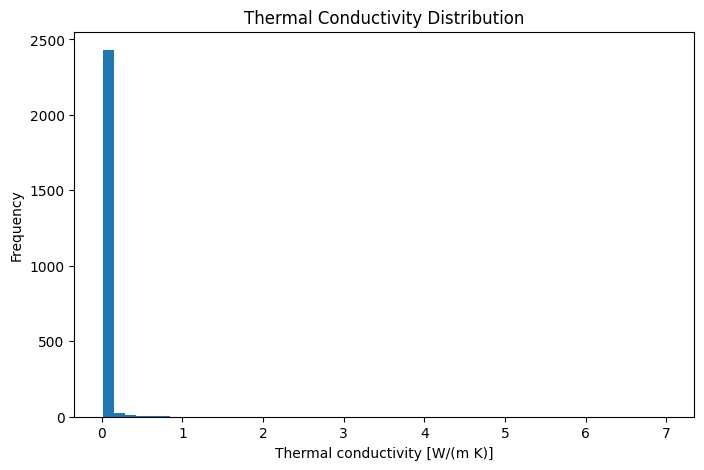

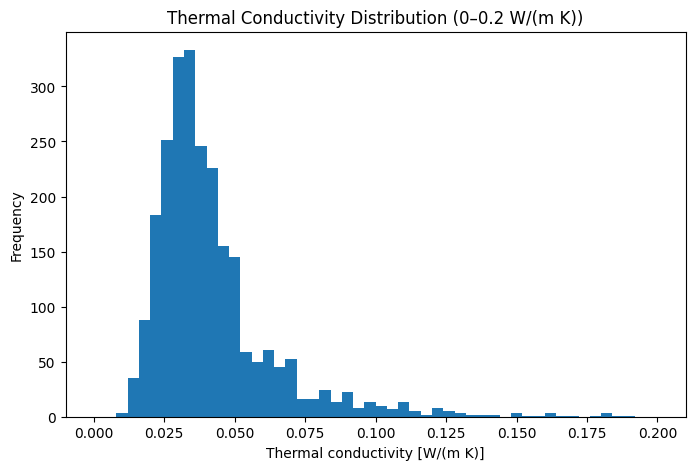

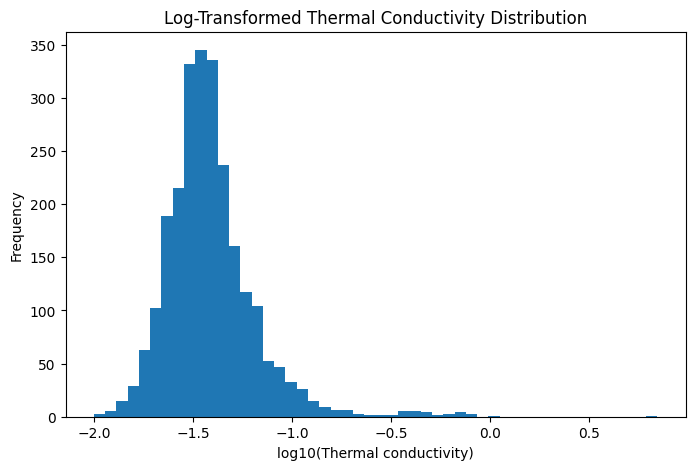

In [348]:
plt.figure(figsize=(8, 5))
plt.hist(df['Thermal_conductivity'], bins=50)

plt.xlabel('Thermal conductivity [W/(m K)]')
plt.ylabel('Frequency')
plt.title('Thermal Conductivity Distribution')

plt.show()

plt.figure(figsize=(8, 5))
plt.hist(
    df['Thermal_conductivity'],
    bins=50,
    range=(0, 0.2)
)

plt.xlabel('Thermal conductivity [W/(m K)]')
plt.ylabel('Frequency')
plt.title('Thermal Conductivity Distribution (0–0.2 W/(m K))')

plt.show()

plt.figure(figsize=(8, 5))
plt.hist(
    np.log10(df['Thermal_conductivity']),
    bins=50
)

plt.xlabel('log10(Thermal conductivity)')
plt.ylabel('Frequency')
plt.title('Log-Transformed Thermal Conductivity Distribution')

plt.show()

In [349]:

# Count values between 0 and 1

print(f'Total values: {df["Thermal_conductivity"].notna().sum()}')
count_0_1 = df['Thermal_conductivity'].between(0, 1).sum()

print(f'TARGET: Values of thermal conductivity between 0 and 1: {count_0_1}')
print(
    f'Percentage between 0 and 1: '
    f'{count_0_1 / df["Thermal_conductivity"].notna().sum() * 100:.2f}%'
)

# Only one sample has a thermal conductivity above 1 W/(m K).
# This value should be investigated before deciding whether it is an outlier.


# Count values between 0 and 0.2
count_0_2 = df['Thermal_conductivity'].between(0, 0.2).sum()

print(f'TARGET: Values of thermal conductivity between 0 and 0.2: {count_0_2}')
print(
    f'Percentage between 0 and 0.2: '
    f'{count_0_2 / df["Thermal_conductivity"].notna().sum() * 100:.2f}%'
)


# Only 38 sample has a thermal conductivity above 0.2 W/(m K).



Total values: 2484
TARGET: Values of thermal conductivity between 0 and 1: 2483
Percentage between 0 and 1: 99.96%
TARGET: Values of thermal conductivity between 0 and 0.2: 2446
Percentage between 0 and 0.2: 98.47%


Thermal conductivity presents a strongly right-skewed distribution. Most observations are concentrated in the low-conductivity region, with approximately 98.5% of the samples below 0.2 W/(m·K), while a small number of observations extend to considerably higher values.

In [350]:
# Inspect the sample with thermal conductivity = 7

display(
    df[df['Thermal_conductivity'] == 7].T
)

,6642
Entry,6643
Drying,FD
Purpose,Not specific
Shape,Monolith
First materials,GO
Second materials,Epoxy
Modification,Carbonized
First material class,N
Second materials class,F
Modification class,Ca


In [351]:
# Find samples with similar material and thermal measurement method

similar_samples = df[
    (df['First materials'] == 'GO') &
    (df['Thermal method detail'] == 'Flash')
].sort_values('Thermal_conductivity', ascending=False)

display(
    similar_samples[
        [
            'Entry',
            'Drying',
            'First materials',
            'Second materials',
            'Modification',
            'Shape',
            'Thermal_conductivity',
            'Thermal method',
            'Thermal method detail'
        ]
    ]
)


,Entry,Drying,First materials,Second materials,Modification,Shape,Thermal_conductivity,Thermal method,Thermal method detail
6642,6643,FD,GO,Epoxy,Carbonized,Monolith,7.000,Transient,Flash
6641,6642,FD,GO,Epoxy,NaN,Monolith,1.000,Transient,Flash
4518,4519,FD,GO,Polyamide,NaN,Monolith,0.847,Transient,Flash
6475,6476,FD,GO,Cellulose,NaN,Monolith,0.670,Transient,Flash
10909,10910,FD,GO,"PVA, epoxy",NaN,Monolith,0.592,Transient,Flash
10908,10909,FD,GO,"PVA, epoxy",NaN,Monolith,0.493,Transient,Flash


In [352]:
carbonized = df[
    df['Modification'].str.contains('Carbonized', case=False, na=False)
].sort_values('Thermal_conductivity', ascending=False)

display(
    carbonized[
        [
            'Entry',
            'Drying',
            'First materials',
            'Second materials',
            'Modification',
            'Shape',
            'Thermal_conductivity',
            'Thermal method',
            'Thermal method detail',
            'Density',
            'Purpose'
        ]
    ]
)

,Entry,Drying,First materials,Second materials,Modification,Shape,Thermal_conductivity,Thermal method,Thermal method detail,Density,Purpose
6642,6643,FD,GO,Epoxy,Carbonized,Monolith,7.00000,Transient,Flash,NaN,Not specific
9731,9732,APD,RF,NaN,Carbonized,Monolith,0.15440,Steady state,GHP,1.15000,Not specific
9719,9720,APD,RF,NaN,Carbonized,Monolith,0.13560,Steady state,GHP,0.80000,Not specific
9730,9731,APD,RF,NaN,Carbonized,Monolith,0.12000,Steady state,GHP,0.55000,Not specific
9728,9729,APD,RF,NaN,Carbonized,Monolith,0.11390,Steady state,GHP,0.60000,Not specific
9732,9733,APD,RF,NaN,Carbonized,Monolith,0.11390,Steady state,GHP,0.45000,Not specific
9725,9726,APD,RF,NaN,Carbonized,Monolith,0.10490,Steady state,GHP,0.90000,Not specific
9724,9725,APD,RF,NaN,Carbonized,Monolith,0.09860,Steady state,GHP,0.40000,Not specific
9722,9723,APD,RF,NaN,Carbonized,Monolith,0.09710,Steady state,GHP,0.65000,Not specific
9733,9734,APD,RF,NaN,Carbonized,Monolith,0.07610,Steady state,GHP,0.35000,Not specific


The value of 7.000 W/m·K initially appeared as a strong outlier compared with most other samples in the dataset, including other samples labelled as "Carbonized". However, further investigation showed that high thermal conductivity values can be physically plausible for graphene-based aerogels when the carbon structure is highly graphitized and/or structurally aligned.

In particular, literature reports thermal conductivities in the range of several W/m·K for highly graphitized and directionally aligned graphene aerogels, which is substantially higher than the values typically observed for conventional, disordered porous carbon aerogels.

Therefore, the value cannot be considered a data-entry error based on its magnitude alone. Instead, it highlights a limitation of the current categorical representation: the "Modification" variable groups potentially very different processes under the same label, such as conventional carbonization and high-temperature graphitization.

The value was therefore retained in the dataset. For the subsequent modelling stage, extreme-value analysis should consider material type, processing conditions and measurement method rather than applying a single global threshold to thermal conductivity.

**The value of 7 W/(m·K) is statistically extreme but cannot be classified as erroneous based solely on its magnitude. Its material composition and processing differ from most low-conductivity aerogels, and relatively high conductivities are also observed in other graphene-based samples. Therefore, the sample is retained and treated as a physically plausible extreme observation.**

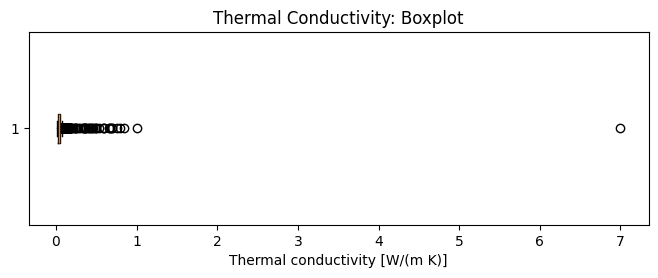

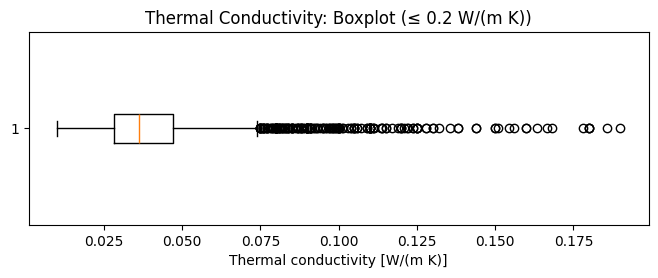

In [353]:
plt.figure(figsize=(8, 2.5))
plt.boxplot(
    df['Thermal_conductivity'],
    vert=False
)
plt.xlabel('Thermal conductivity [W/(m K)]')
plt.title('Thermal Conductivity: Boxplot')
plt.show()

plt.figure(figsize=(8, 2.5))
plt.boxplot(
    df.loc[
        df['Thermal_conductivity'] <= 0.2,
        'Thermal_conductivity'
    ],
    vert=False
)
plt.xlabel('Thermal conductivity [W/(m K)]')
plt.title('Thermal Conductivity: Boxplot (≤ 0.2 W/(m K))')
plt.show()

In [354]:
# Basic statistics of the target variable
print(df['Thermal_conductivity'].describe())
numerical_columns = df.select_dtypes(include='float64').columns


numerical_summary = pd.DataFrame({
    'Available': df[numerical_columns].notna().sum(),
    'Missing': df[numerical_columns].isna().sum(),
    'Missing (%)': df[numerical_columns].isna().mean() * 100
})

display(numerical_summary)

count    2484.000000
mean        0.050934
std         0.152535
min         0.010000
25%         0.028522
50%         0.036550
75%         0.048000
max         7.000000
Name: Thermal_conductivity, dtype: float64


,Available,Missing,Missing (%)
Density,2210,274,11.030596
Porosity,1405,1079,43.438003
BET,959,1525,61.392915
Pore_size,160,2324,93.558776
Pore_volume,318,2166,87.198068
Elastic_modulus,827,1657,66.706924
Thermal_conductivity,2484,0,0.000000


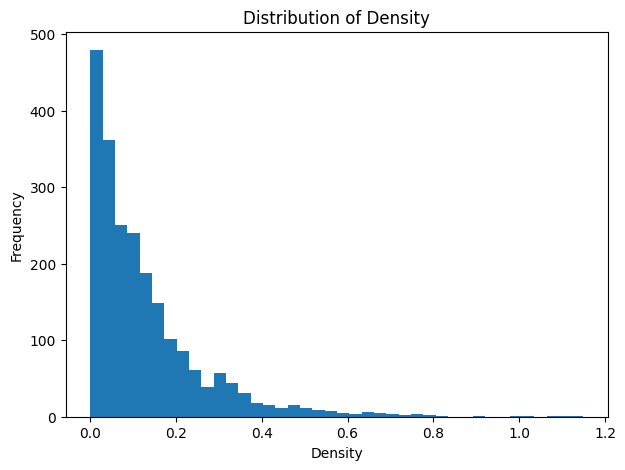

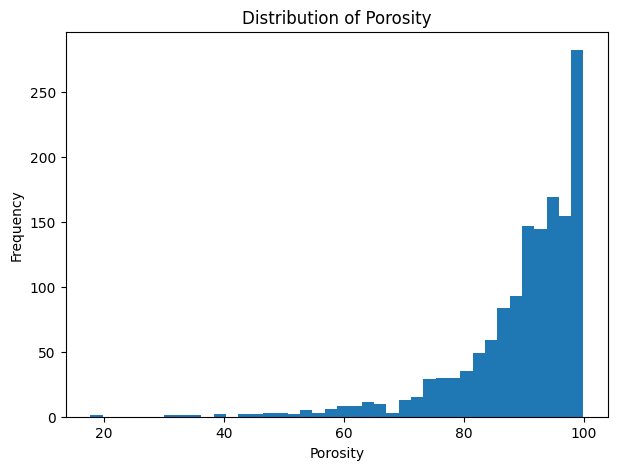

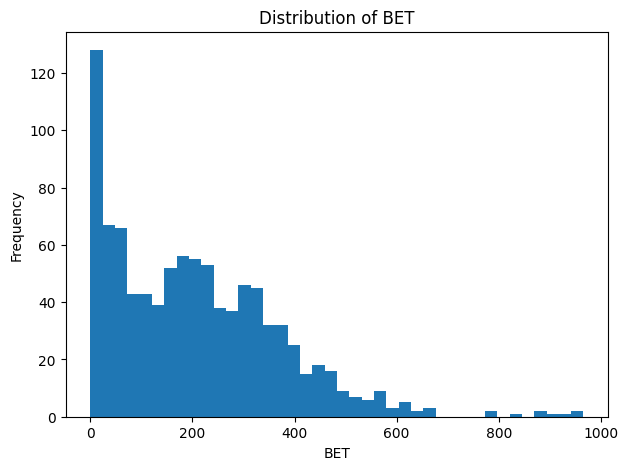

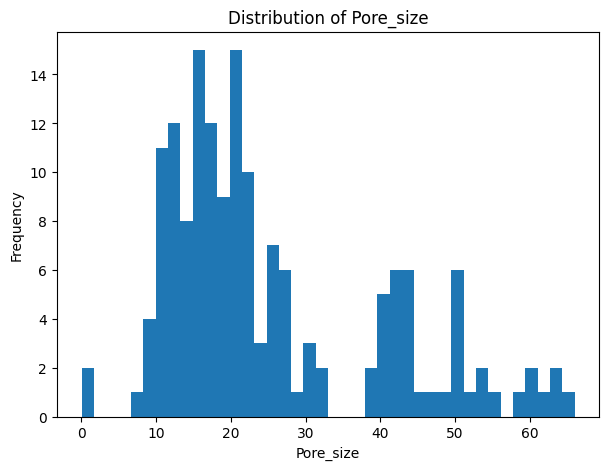

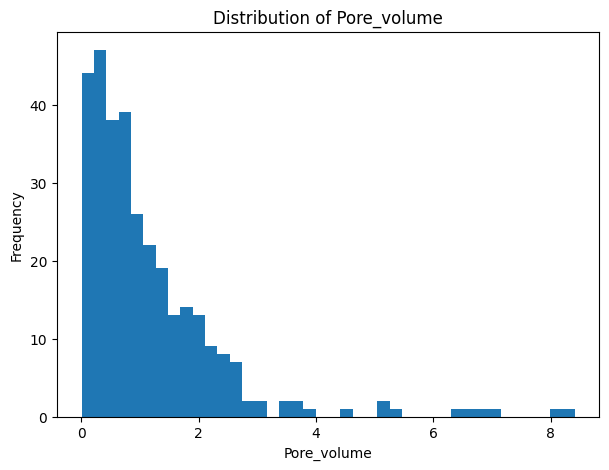

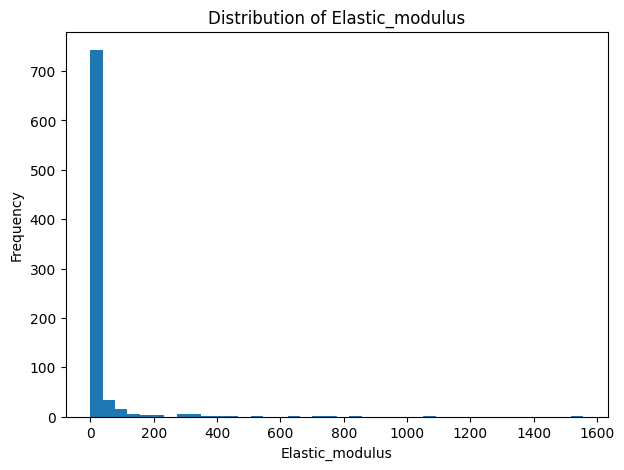

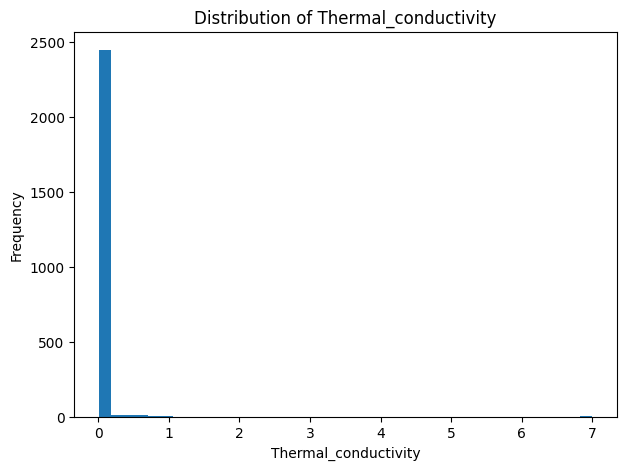

In [355]:

for col in numerical_columns:
    plt.figure(figsize=(7, 5))

    plt.hist(df[col].dropna(), bins=40)

    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')

    plt.show()

In [356]:
display(df[numerical_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
Density,2210.0,0.129133,0.137704,0.0005,0.035000,0.08870,0.170,1.15
Porosity,1405.0,89.493559,10.515960,17.7000,86.000000,92.30000,96.900,99.97
BET,959.0,207.128367,164.915259,0.0630,64.000000,188.00000,310.500,966.00
Pore_size,160.0,25.290625,14.640818,0.0500,15.000000,20.60000,32.700,66.00
Pore_volume,318.0,1.159815,1.245880,0.0030,0.380000,0.80450,1.500,8.41
Elastic_modulus,827.0,25.851266,100.113102,0.0001,0.150000,1.72000,13.250,1557.00
Thermal_conductivity,2484.0,0.050934,0.152535,0.0100,0.028522,0.03655,0.048,7.00


Inspection of the most extreme values in Density and BET shows that they correspond to different materials and processing conditions and are physically plausible.

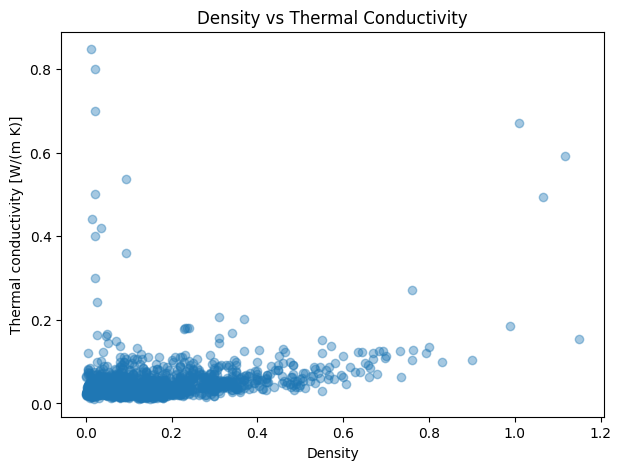

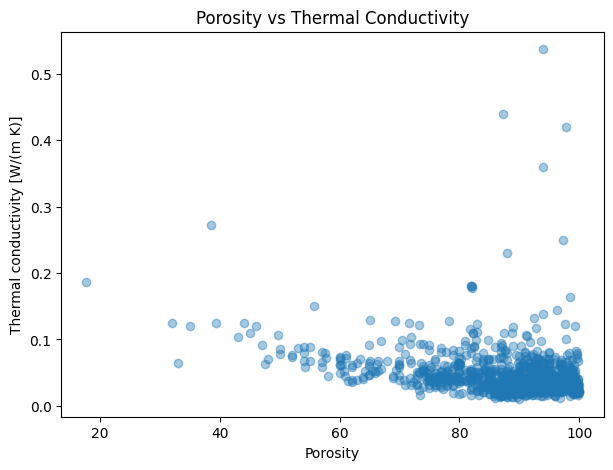

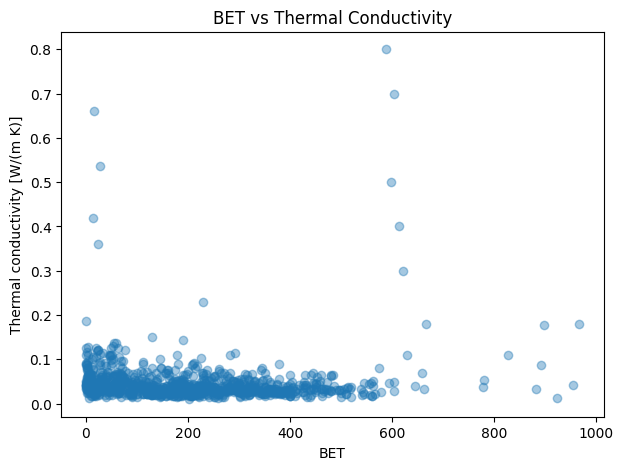

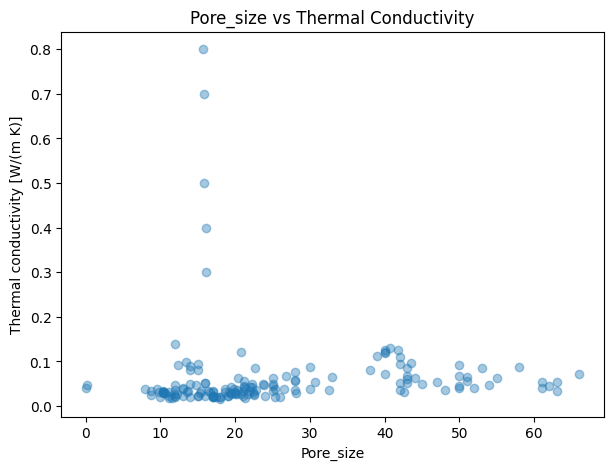

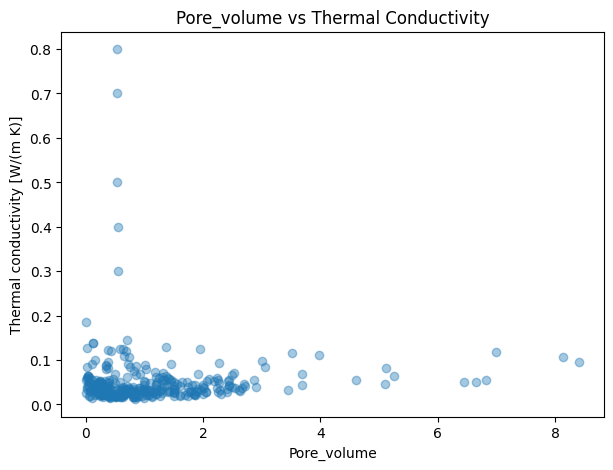

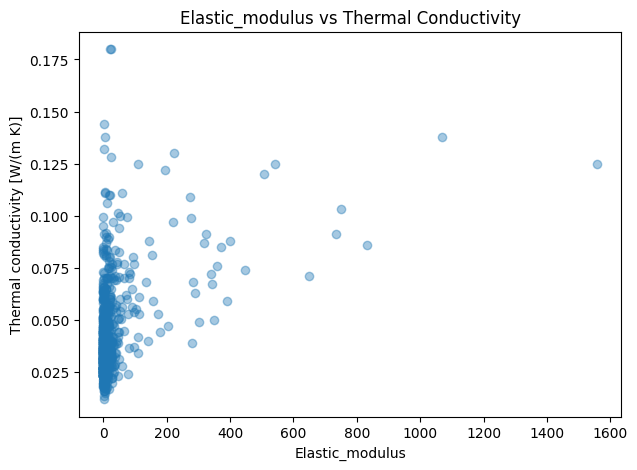

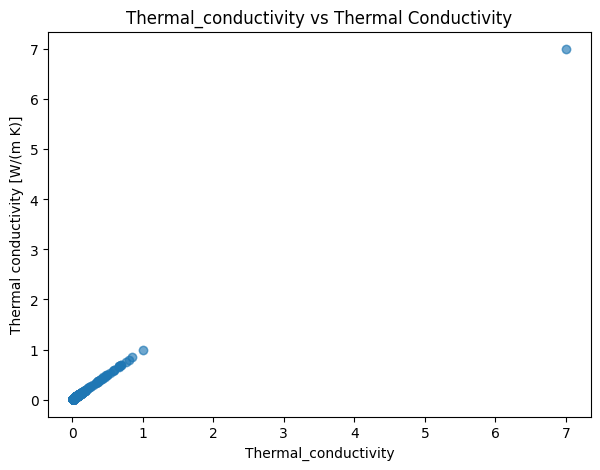

In [357]:
for col in numerical_columns:

    temp = df[[col, 'Thermal_conductivity']].dropna()

    plt.figure(figsize=(7, 5))

    plt.scatter(
        temp[col],
        temp['Thermal_conductivity'],
        alpha=0.4
    )

    plt.xlabel(col)
    plt.ylabel('Thermal conductivity [W/(m K)]')
    plt.title(f'{col} vs Thermal Conductivity')

    plt.show()

Some trends can be observed between thermal conductivity, density and porosity.




,Density,Porosity,BET,Pore_size,Pore_volume,Elastic_modulus,Thermal_conductivity
Density,1.000000,-0.908541,-0.168160,0.469941,-0.022974,0.621474,0.293216
Porosity,-0.908541,1.000000,0.213830,-0.541690,0.068288,-0.698242,-0.306439
BET,-0.168160,0.213830,1.000000,-0.317354,0.143587,-0.166333,0.012440
Pore_size,0.469941,-0.541690,-0.317354,1.000000,0.483990,0.002485,0.009292
Pore_volume,-0.022974,0.068288,0.143587,0.483990,1.000000,-0.148083,0.015475
Elastic_modulus,0.621474,-0.698242,-0.166333,0.002485,-0.148083,1.000000,0.421694
Thermal_conductivity,0.293216,-0.306439,0.012440,0.009292,0.015475,0.421694,1.000000


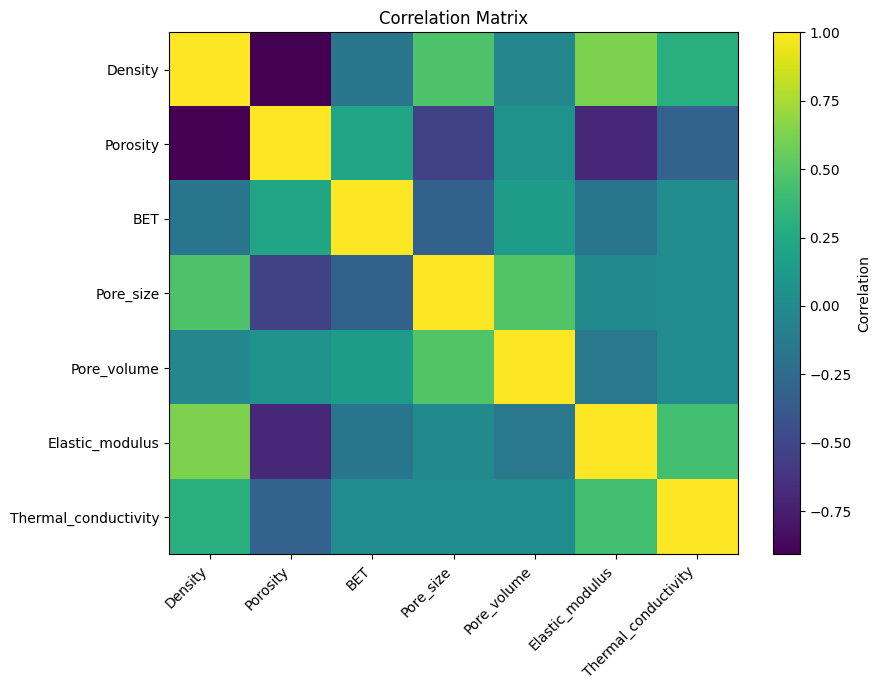

In [358]:
# Correlation matrix to see relations between target and other numerical variables
correlation_matrix = df[numerical_columns].corr()

display(correlation_matrix)

plt.figure(figsize=(9, 7))

plt.imshow(correlation_matrix, aspect='auto')

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.colorbar(label='Correlation')

plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

Density shows a positive association with thermal conductivity, whereas porosity shows a negative association. These trends are physically consistent with the reduction in solid-phase heat-transfer pathways as porosity increases.

However, these relationships should not be interpreted as isolated causal effects because density and porosity are themselves strongly correlated and also depend on material composition and processing.

In [359]:
pearson_corr = df[numerical_columns].corr(
    method='pearson'
)

spearman_corr = df[numerical_columns].corr(
    method='spearman'
)

display(pearson_corr)
display(spearman_corr)

,Density,Porosity,BET,Pore_size,Pore_volume,Elastic_modulus,Thermal_conductivity
Density,1.000000,-0.908541,-0.168160,0.469941,-0.022974,0.621474,0.293216
Porosity,-0.908541,1.000000,0.213830,-0.541690,0.068288,-0.698242,-0.306439
BET,-0.168160,0.213830,1.000000,-0.317354,0.143587,-0.166333,0.012440
Pore_size,0.469941,-0.541690,-0.317354,1.000000,0.483990,0.002485,0.009292
Pore_volume,-0.022974,0.068288,0.143587,0.483990,1.000000,-0.148083,0.015475
Elastic_modulus,0.621474,-0.698242,-0.166333,0.002485,-0.148083,1.000000,0.421694
Thermal_conductivity,0.293216,-0.306439,0.012440,0.009292,0.015475,0.421694,1.000000


,Density,Porosity,BET,Pore_size,Pore_volume,Elastic_modulus,Thermal_conductivity
Density,1.000000,-0.867119,-0.126360,0.459527,0.100657,0.714403,0.272926
Porosity,-0.867119,1.000000,0.226706,-0.629896,-0.145558,-0.705239,-0.307086
BET,-0.126360,0.226706,1.000000,-0.274291,0.426702,0.023379,-0.232061
Pore_size,0.459527,-0.629896,-0.274291,1.000000,0.485116,0.233676,0.408223
Pore_volume,0.100657,-0.145558,0.426702,0.485116,1.000000,0.217044,0.071095
Elastic_modulus,0.714403,-0.705239,0.023379,0.233676,0.217044,1.000000,0.329568
Thermal_conductivity,0.272926,-0.307086,-0.232061,0.408223,0.071095,0.329568,1.000000


Pearson responde aproximadamente:

¿Existe una relación lineal entre estas dos variables?

Por ejemplo:

$$ Density \uparrow \quad \Rightarrow \quad k \uparrow $$

si aumenta aproximadamente siguiendo una recta.

Spearman responde:

¿Cuando una variable aumenta, la otra tiende generalmente a aumentar o disminuir, aunque la relación no sea una recta?

Esto es especialmente interesante en materiales porque podemos tener algo como:

$$ k = a\rho^n $$

que no es estrictamente lineal.

La idea clave es:

Pearson: relación lineal.
Spearman: relación monotónica, aunque no sea una recta.

Viendo tus resultados:

Density → Thermal conductivity

Pearson: +0.293
Spearman: +0.273

Son bastante parecidos. Eso sugiere una relación positiva real pero moderada: en general, a mayor densidad, mayor conductividad térmica. No parece haber una gran no linealidad aquí.

Porosity → Thermal conductivity

Pearson: -0.306
Spearman: -0.307

Prácticamente idénticos. Muy buena señal: la relación negativa es bastante consistente. A mayor porosidad, menor conductividad térmica. Además, esto tiene sentido físico.

Elastic modulus → Thermal conductivity

Pearson: +0.422
Spearman: +0.330

Aquí Pearson es bastante mayor. Esto puede indicar que algunos valores extremos están reforzando la relación lineal. Sigue habiendo una asociación positiva, pero probablemente menos fuerte de lo que Pearson hace parecer.

BET → Thermal conductivity

Pearson: +0.012
Spearman: -0.232

Esto es muy interesante. Pearson dice prácticamente “no hay relación lineal”, pero Spearman sí detecta una tendencia negativa moderada. Eso puede significar que, en general, cuando BET aumenta, la conductividad tiende a disminuir, pero la relación no sigue una recta simple.

Pore size → Thermal conductivity

Pearson: +0.009
Spearman: +0.408

Este es probablemente el resultado más llamativo. Pearson dice “casi cero relación lineal”, mientras que Spearman detecta una relación positiva moderada. Es un indicio claro de una relación no lineal o afectada por extremos.

Pore volume → Thermal conductivity

Pearson: +0.015
Spearman: +0.071

En ambos casos la relación es muy débil. A priori parece una variable con poca asociación marginal con el target.

Hay otro resultado importante que no es directamente con el target:

Density y Porosity:
Pearson: -0.909
Spearman: -0.867

Eso es una relación fortísima. Básicamente contienen mucha información redundante.

También:

Density vs Elastic modulus: Spearman +0.714
Porosity vs Elastic modulus: Spearman -0.705

Esto sugiere que los materiales más densos tienden a ser más rígidos, mientras que los más porosos tienden a ser menos rígidos.

Qué conclusión pondría en el notebook

Podrías escribir algo así:

Pearson and Spearman correlations show consistent moderate associations between thermal conductivity and density, porosity and elastic modulus. Density is positively associated with thermal conductivity, whereas porosity shows a negative association.

Differences between Pearson and Spearman correlations indicate that some relationships may be nonlinear. In particular, BET surface area and pore size show weak Pearson correlations but more substantial Spearman correlations, suggesting monotonic trends that are not well described by a linear relationship.

Density and porosity are strongly negatively correlated, indicating substantial redundancy between these descriptors. Elastic modulus is also strongly associated with density and porosity.

These results suggest that nonlinear machine-learning models may be more appropriate than purely linear models for capturing some of the relationships present in the dataset.

In [360]:
# EDA Conclusions
#
# - Thermal conductivity is strongly right-skewed, with 99.96% of the measured
#   values between 0 and 1 W/(m K).
# - One sample has a thermal conductivity of 7 W/(m K) and should be investigated
#   before deciding whether it is a valid measurement or an outlier.
# - Density and porosity show visible trends with thermal conductivity.
# - Elastic modulus shows a moderate positive correlation with thermal conductivity
#   among the subset of samples where modulus measurements are available.
# - Density and porosity are strongly negatively correlated (-0.91), which should
#   be considered when developing the ML models.
# - BET, pore size, pore volume and elastic modulus contain substantial missing data,
#   which will need to be addressed during preprocessing.

In [361]:
for col in numerical_columns:

    df[f'{col}_available'] = df[col].notna()

    summary = (
        df.groupby(f'{col}_available')['Thermal_conductivity']
        .agg(['count', 'mean', 'median'])
    )

    display(summary)

,count,mean,median
Density_available,,,
False,274,0.098080,0.03600
True,2210,0.045089,0.03685


,count,mean,median
Porosity_available,,,
False,1079,0.060255,0.036
True,1405,0.043776,0.037


,count,mean,median
BET_available,,,
False,1525,0.053238,0.037
True,959,0.047270,0.036


,count,mean,median
Pore_size_available,,,
False,2324,0.050125,0.03639
True,160,0.062683,0.03900


,count,mean,median
Pore_volume_available,,,
False,2166,0.050752,0.03675
True,318,0.052179,0.03600


,count,mean,median
Elastic_modulus_available,,,
False,1657,0.054931,0.036
True,827,0.042926,0.038


,count,mean,median
Thermal_conductivity_available,,,
True,2484,0.050934,0.03655


The availability of numerical descriptors was compared with the thermal conductivity distribution to assess whether missing values may be systematically associated with the target. Median thermal conductivity is relatively similar between samples with and without available measurements for most numerical variables. However, some descriptors, particularly pore size and pore volume, are available only for a small subset of the dataset. Therefore, missingness cannot be assumed to be completely random and should be handled carefully during preprocessing.

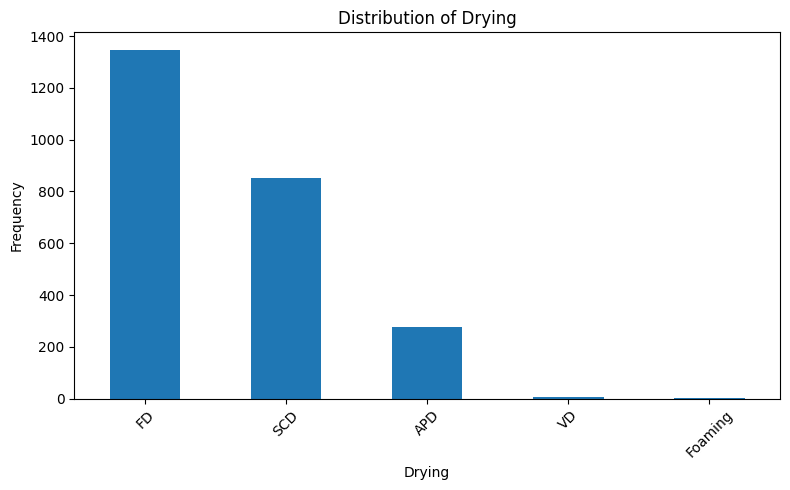

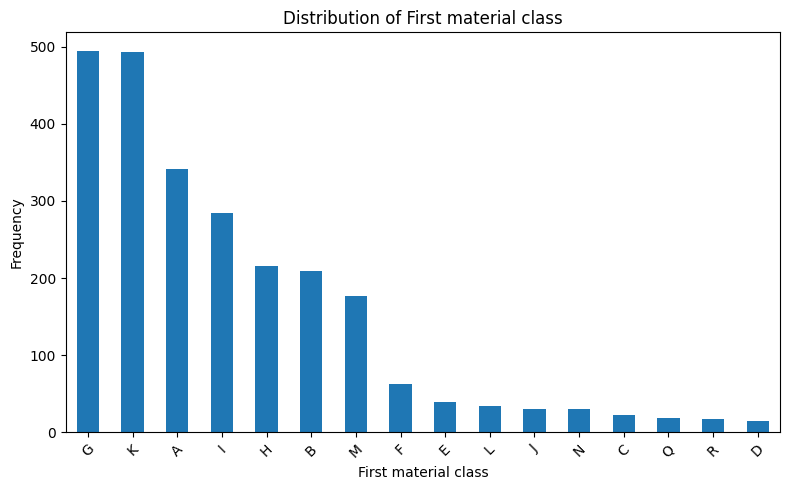

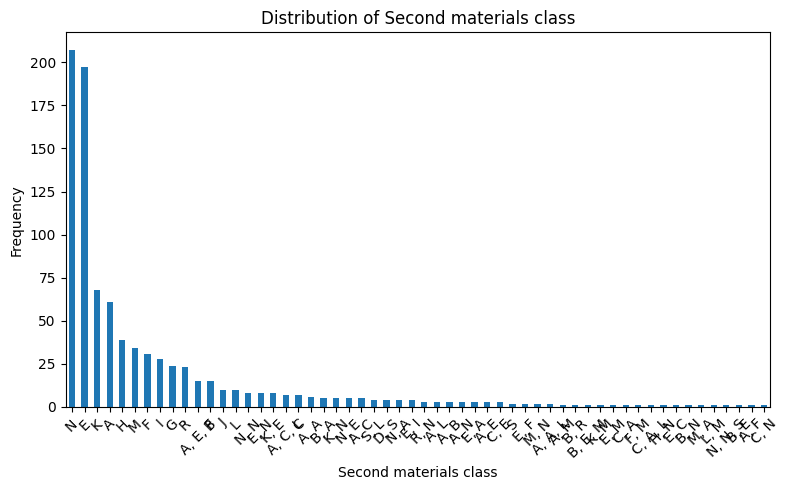

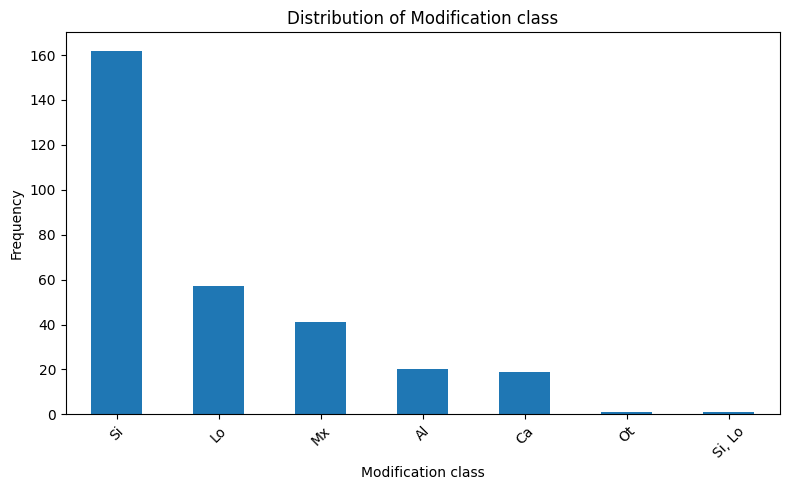

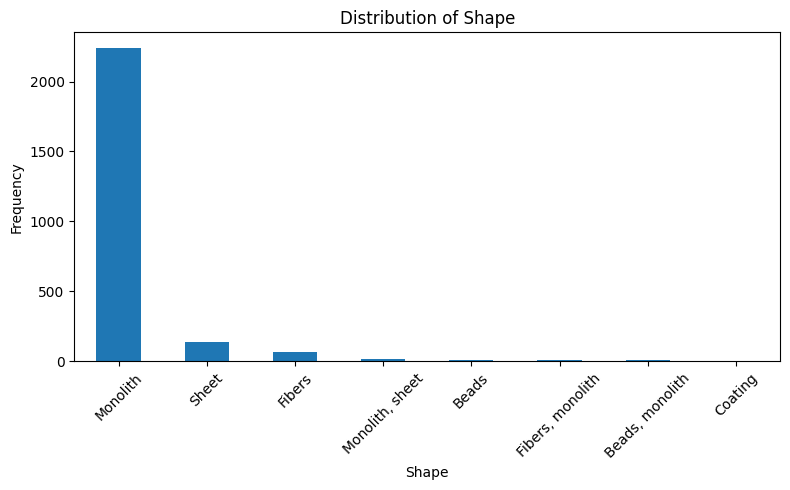

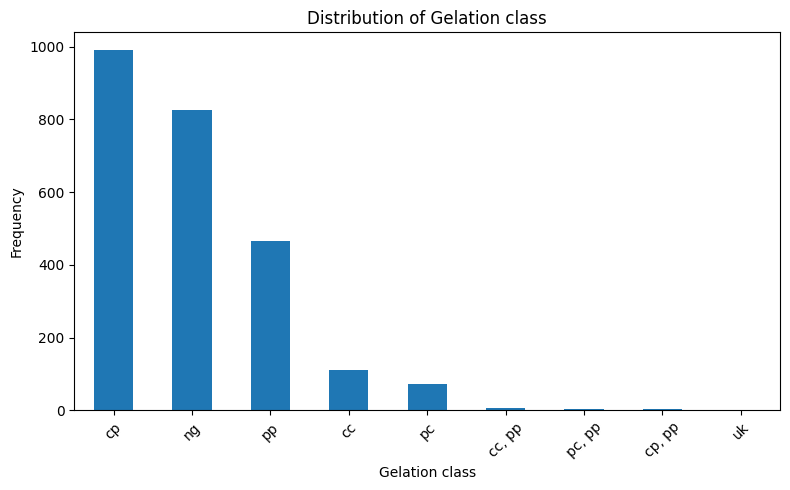

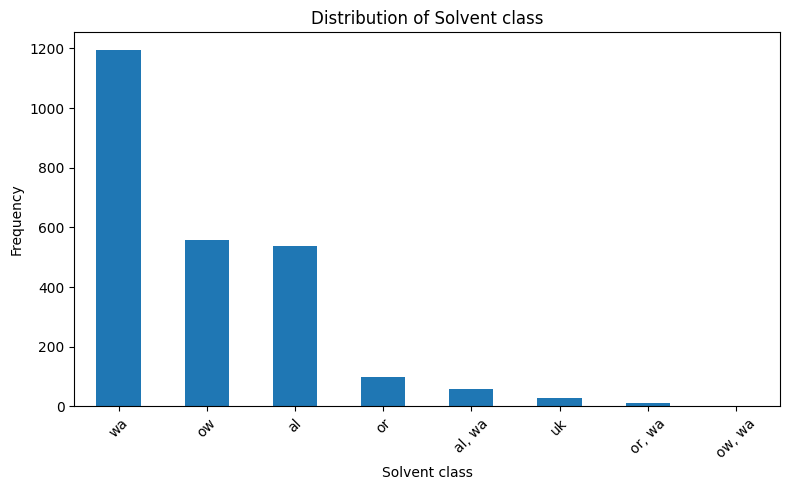

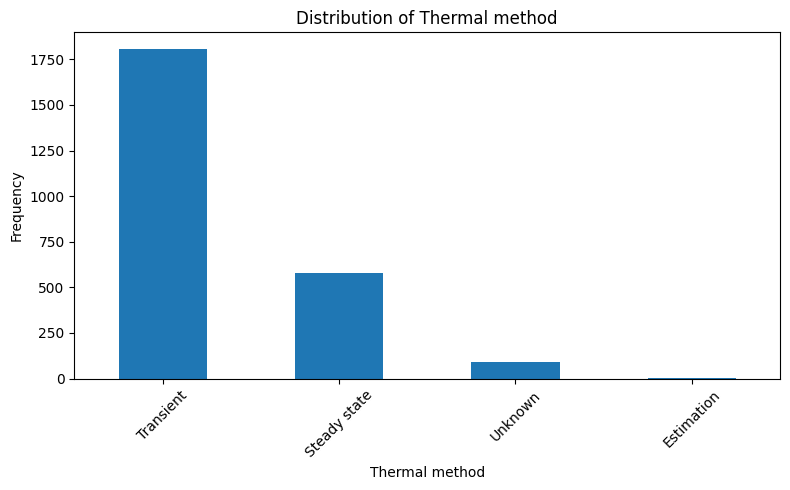

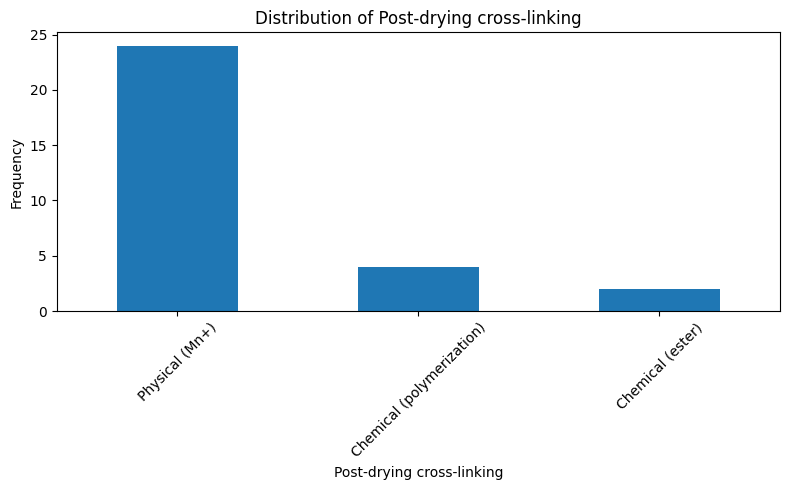

In [362]:
categorical_features=[
    'Drying',
    'First material class',
    'Second materials class',
    'Modification class',
    'Shape',
    'Gelation class',
    'Solvent class',
    'Thermal method',
    'Post-drying cross-linking'
]

for col in categorical_features:
    plt.figure(figsize=(8, 5))

    df[col].value_counts().plot(kind='bar')

    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')

    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

In [363]:
for col in categorical_features:

    print(f'\n--- {col} ---')

    summary = (
        df.groupby(col)['Thermal_conductivity']
        .agg(['count', 'mean', 'median', 'std'])
        .sort_values('count', ascending=False)
    )

    display(summary)


--- Drying ---


,count,mean,median,std
Drying,,,,
FD,1347,0.056684,0.0380,0.203087
SCD,851,0.039246,0.0301,0.044417
APD,276,0.058938,0.0480,0.038046
VD,7,0.038669,0.0422,0.006972
Foaming,3,0.077333,0.0760,0.004163



--- First material class ---


,count,mean,median,std
First material class,,,,
G,494,0.040040,0.03503,0.017546
K,493,0.046750,0.03500,0.067658
A,342,0.042801,0.03900,0.023401
I,285,0.047394,0.03700,0.037291
H,216,0.043498,0.03690,0.023948
B,209,0.048747,0.03600,0.051776
M,177,0.060495,0.04110,0.069490
F,63,0.033252,0.03120,0.012672
E,39,0.043215,0.03600,0.018677



--- Second materials class ---


...

,count,mean,median,std
Solvent class,,,,
wa,1194,0.058626,0.03850,0.215492
ow,557,0.038408,0.03200,0.021242
al,537,0.047437,0.03427,0.053035
or,100,0.048229,0.03800,0.028962
"al, wa",58,0.045759,0.04020,0.017829
uk,27,0.070636,0.03970,0.112298
"or, wa",10,0.025520,0.02600,0.004972
"ow, wa",1,0.015800,0.01580,NaN



--- Thermal method ---


,count,mean,median,std
Thermal method,,,,
Transient,1808,0.056032,0.0384,0.177885
Steady state,581,0.036088,0.0290,0.024231
Unknown,92,0.045044,0.0370,0.028374
Estimation,3,0.034800,0.0300,0.008839



--- Post-drying cross-linking ---


,count,mean,median,std
Post-drying cross-linking,,,,
Physical (Mn+),24,0.061788,0.03755,0.061177
Chemical (polymerization),4,0.037750,0.03750,0.001708
Chemical (ester),2,0.029500,0.02950,0.006364


<Figure size 1000x500 with 0 Axes>

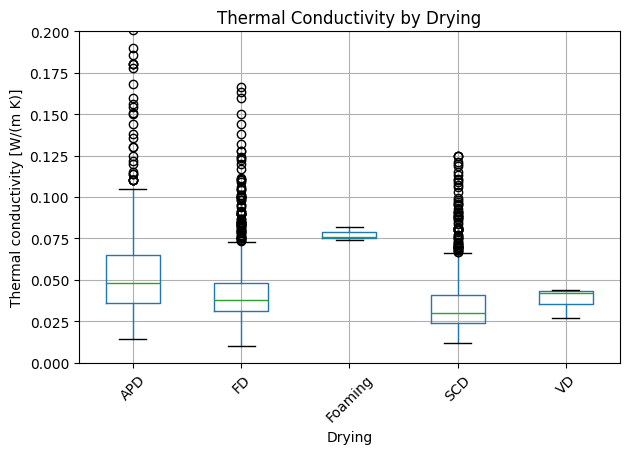

<Figure size 1000x500 with 0 Axes>

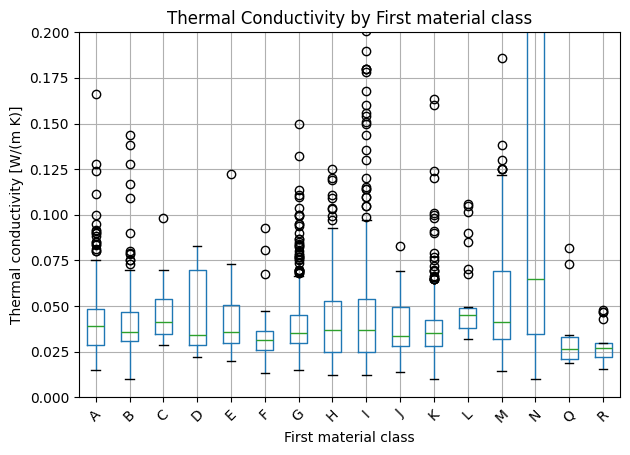

<Figure size 1000x500 with 0 Axes>

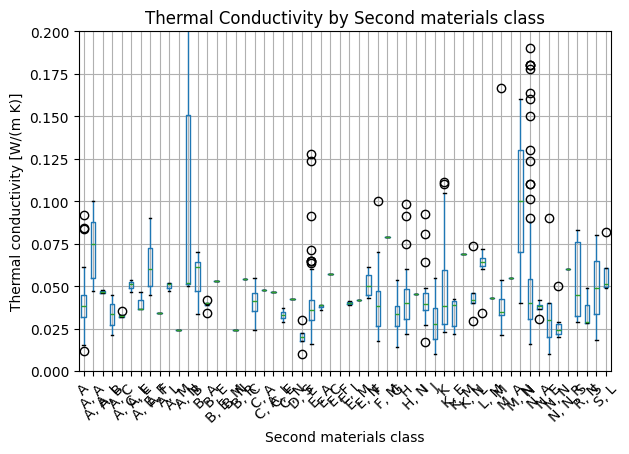

<Figure size 1000x500 with 0 Axes>

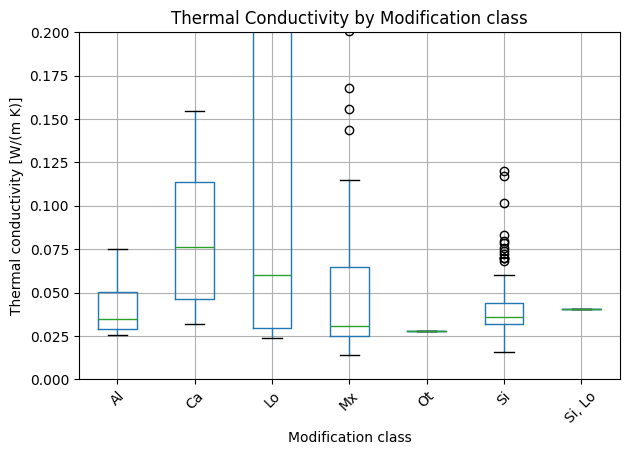

<Figure size 1000x500 with 0 Axes>

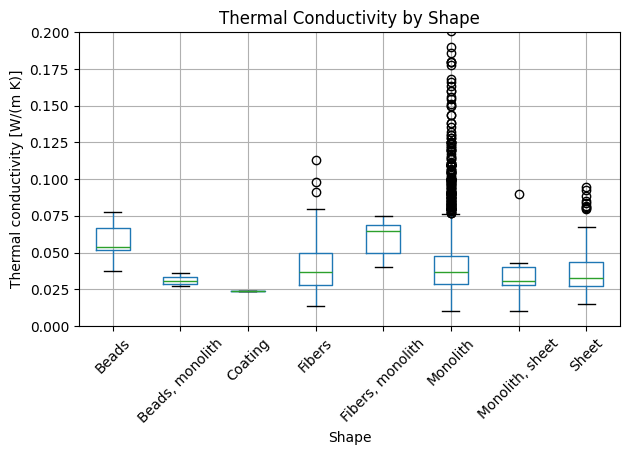

<Figure size 1000x500 with 0 Axes>

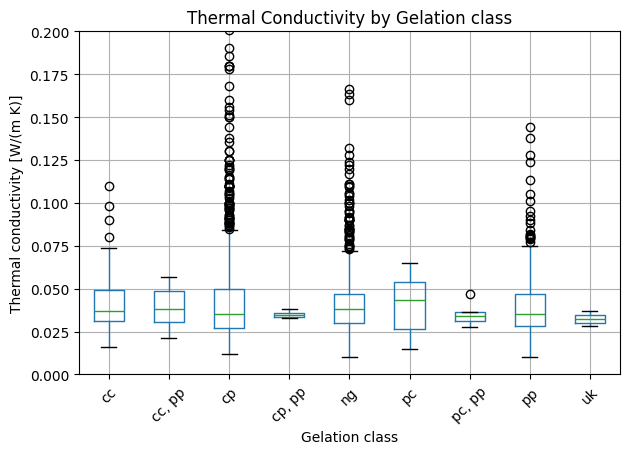

<Figure size 1000x500 with 0 Axes>

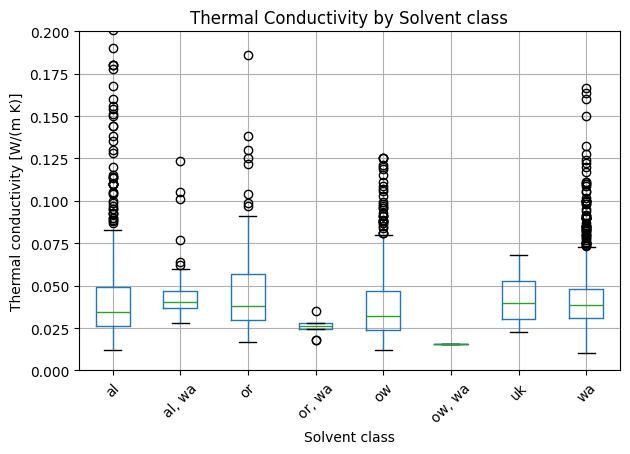

<Figure size 1000x500 with 0 Axes>

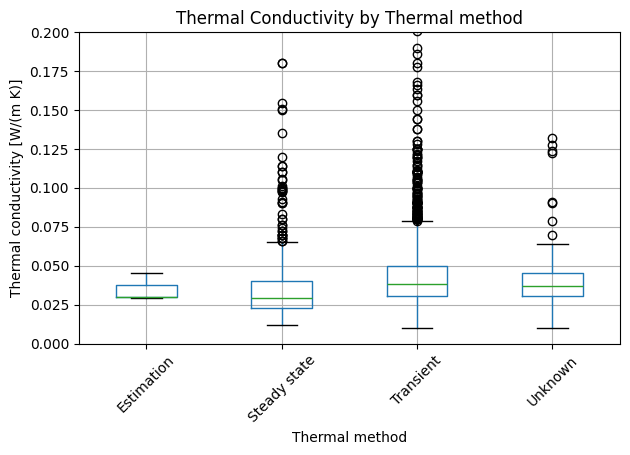

<Figure size 1000x500 with 0 Axes>

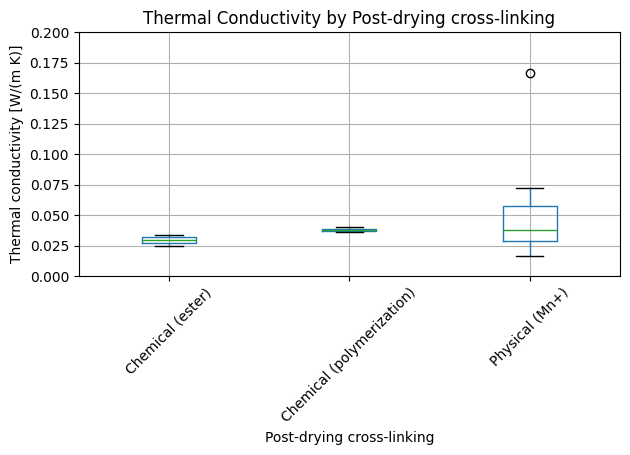

In [364]:
for col in categorical_features:
    plt.figure(figsize=(10, 5))

    df.boxplot(
        column='Thermal_conductivity',
        by=col
    )
    plt.ylim(0, 0.2)
    plt.xlabel(col)
    plt.ylabel('Thermal conductivity [W/(m K)]')
    plt.title(f'Thermal Conductivity by {col}')

    plt.suptitle('')
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

Differences between measurement methods are investigated as potential experimental heterogeneity, but measurement-method variables are excluded from predictive models because they are not material-design parameters.

Some Shape values contain multiple forms (e.g., "Monolith, sheet"). Treating them as single categories is not an ideal representation. We will address this later by converting Shape into separate binary features. This also happens to other features like purpose.

In [365]:
# Categorical EDA Conclusions
#
# - Drying, Shape, Thermal method and the class variables show different
#   distributions of samples across their categories.
# - The boxplots suggest that thermal conductivity may vary between some
#   categorical groups, although several categories contain relatively few
#   observations.
# - Shape contains multi-label categories such as "Monolith, sheet" and
#   "Fibers, monolith", which should be transformed into separate binary
#   features during feature engineering.
# - Purpose, material and modification variables contain many categories,
#   so their representation should be considered carefully before encoding.
# - Process contains a very large number of unique values and should not be
#   directly one-hot encoded.
# - Some categorical variables contain class/group information that may provide
#   a more compact representation of the original material or modification
#   information.

EDA conclusions

Thermal conductivity is strongly right-skewed, with most observations concentrated below 0.2 W/(m·K) and a small number of substantially higher values.

The extreme observations are not automatically removed, since some correspond to physically distinct material systems such as carbon-based aerogels.

Density shows a positive association with thermal conductivity, whereas porosity shows a negative association. Density and porosity are themselves strongly negatively correlated, indicating substantial redundancy between these descriptors.

Several physical descriptors contain large amounts of missing information, particularly pore size and pore volume. Their contribution should therefore be evaluated through model comparison rather than assumed a priori.

Categorical variables show differences in thermal-conductivity distributions between material and processing groups, although many rare categories contain too few observations for robust standalone interpretation.

The strong skewness of the target motivates testing both the original thermal-conductivity scale and a logarithmic target transformation during model development.

Overall conclusion:
The main candidate features identified at this stage are density, porosity,
BET, drying method, shape and material information. Further feature engineering and preprocessing are required before training the first ML models.





# FEATURE ENGINEERING

In [366]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================


# ------------------------------------------------------------
# Shape: multi-label encoding
# ------------------------------------------------------------
# Normalize capitalization within multi-label Shape values

shape_corrections = {
    'monolith': 'Monolith',
    'sheet': 'Sheet',
    'fibers': 'Fibers',
    'beads': 'Beads',
    'coating': 'Coating'
}

df['Shape'] = (
    df['Shape']
    .str.split(',')
    .apply(
        lambda x: ', '.join(
            shape_corrections.get(item.strip().lower(), item.strip())
            for item in x
        ) if isinstance(x, list) else x
    )
)

print(df['Shape'].unique())
shape_features = (
    df['Shape']
    .fillna('')
    .str.get_dummies(sep=', ')
    .add_prefix('Shape_')
)

df = pd.concat([df, shape_features], axis=1)


# ------------------------------------------------------------
# Second material classes: multi-label encoding
# ------------------------------------------------------------

second_class_features = (
    df['Second materials class']
    .fillna('')
    .str.get_dummies(sep=', ')
    .add_prefix('SecondClass_')
)

df = pd.concat([df, second_class_features], axis=1)

df['Has_second_material'] = (
    df['Second materials class']
    .notna()
    .astype(int)
)


# ------------------------------------------------------------
# Gelation classes: multi-label encoding
# ------------------------------------------------------------

gelation_features = (
    df['Gelation class']
    .fillna('')
    .str.get_dummies(sep=', ')
    .add_prefix('Gelation_')
)

df = pd.concat([df, gelation_features], axis=1)


# ------------------------------------------------------------
# Solvent classes: multi-label encoding
# ------------------------------------------------------------

solvent_features = (
    df['Solvent class']
    .fillna('')
    .str.get_dummies(sep=', ')
    .add_prefix('Solvent_')
)

df = pd.concat([df, solvent_features], axis=1)


# ------------------------------------------------------------
# Modification classes: multi-label encoding
# ------------------------------------------------------------

modification_features = (
    df['Modification class']
    .fillna('')
    .str.get_dummies(sep=', ')
    .add_prefix('Modification_')
)

df = pd.concat([df, modification_features], axis=1)

df['Has_modification'] = (
    df['Modification class']
    .notna()
    .astype(int)
)

['Monolith' 'Fibers, Monolith' 'Sheet' 'Fibers' 'Monolith, Sheet'
 'Beads, Monolith' 'Beads' 'Coating']


In [367]:
shape_columns = [
    col for col in df.columns
    if col.startswith('Shape_')
]

second_class_columns = [
    col for col in df.columns
    if col.startswith('SecondClass_')
]

gelation_columns = [
    col for col in df.columns
    if col.startswith('Gelation_')
]

solvent_columns = [
    col for col in df.columns
    if col.startswith('Solvent_')
]

modification_columns = [
    col for col in df.columns
    if col.startswith('Modification_')
]

In [368]:
print("Shape:")
display(df[shape_columns].sum().sort_values(ascending=False))

print("Second material classes:")
display(df[second_class_columns].sum().sort_values(ascending=False))

print("Gelation:")
display(df[gelation_columns].sum().sort_values(ascending=False))

print("Solvents:")
display(df[solvent_columns].sum().sort_values(ascending=False))

print("Modification:")
display(df[modification_columns].sum().sort_values(ascending=False))

Shape:


,0
Shape_Monolith,2268
Shape_Sheet,153
Shape_Fibers,73
Shape_Beads,17
Shape_Coating,1


Second material classes:


,0
SecondClass_E,252
SecondClass_N,249
SecondClass_A,125
SecondClass_K,82
SecondClass_F,50
SecondClass_M,43
SecondClass_H,40
SecondClass_I,32
SecondClass_L,28
SecondClass_R,27


Gelation:


,0
Gelation_cp,994
Gelation_ng,826
Gelation_pp,483
Gelation_cc,118
Gelation_pc,77
Gelation_uk,2


Solvents:


,0
Solvent_wa,1263
Solvent_al,595
Solvent_ow,558
Solvent_or,110
Solvent_uk,27


Modification:


,0
Modification_Si,163
Modification_Lo,58
Modification_Mx,41
Modification_Al,20
Modification_Ca,19
Modification_Ot,1


Solvent class I wouldn't separate because they are mixed probably. CHECK. We dont use purpose because it has too many variables and No describe necesariamente una propiedad física del material.Para el primer modelo:

First material class
Second material classes

en vez de:

First materials
Second materials


Porque las clases generalizan mejor.

REVISAR ESTOOOO

# MODEL CONSTRUCTION

Modelo A — Design-only

Variables tipo:

Drying
First material class

SecondClass_*
Shape_*
Gelation_*
Solvent_*
Modification_*

Has_second_material
Has_modification

Más adelante veremos si añadimos otros parámetros de fabricación.

Modelo B — Characterization-assisted

Todo lo anterior +

Density
Porosity
BET
Pore_size
Pore_volume
Elastic_modulus

Esto nos permitirá responder una pregunta científica bastante buena:

¿Cuánto podemos predecir la conductividad térmica solo a partir del diseño del aerogel, y cuánto mejora la predicción cuando conocemos su estructura física después de fabricarlo?

In [369]:
# ============================================
# FEATURE SETS
# ============================================

design_categorical_features = [
    'Drying',
    'First material class'
]

design_binary_features = (
    shape_columns
    + second_class_columns
    + gelation_columns
    + solvent_columns
    + modification_columns
    + [
        'Has_second_material',
        'Has_modification'
    ]
)

In [370]:
# Design-only model MODEL A ¿Hasta qué punto podemos estimar la conductividad térmica usando únicamente información del diseño y procesado del material?

design_features = (
    design_categorical_features
    + design_binary_features
)

X_design = df[design_features]

y = df['Thermal_conductivity']
print("Design-only model:")
print("X shape:", X_design.shape)
print("y shape:", y.shape)

Design-only model:
X shape: (2484, 42)
y shape: (2484,)


In [371]:
#MODEL B ¿Cuánto mejora la predicción cuando además conocemos propiedades estructurales y físicas del material ya fabricado?
characterization_features = [
    'Density',
    'Porosity',
    'BET',
    'Pore_size',
    'Pore_volume',
    'Elastic_modulus'
]

assisted_features = (
    design_features
    + characterization_features
)

X_assisted = df[assisted_features]

print("Characterization-assisted model:")
print("X shape:", X_assisted.shape)
print("y shape:", y.shape)

Characterization-assisted model:
X shape: (2484, 48)
y shape: (2484,)


In [372]:
print("Design-only features:")
for feature in design_features:
    print(feature)

print("\nCharacterization-assisted additional features:")
for feature in characterization_features:
    print(feature)

Design-only features:
Drying
First material class
Shape_Beads
Shape_Coating
Shape_Fibers
Shape_Monolith
Shape_Sheet
SecondClass_A
SecondClass_B
SecondClass_C
SecondClass_D
SecondClass_E
SecondClass_F
SecondClass_G
SecondClass_H
SecondClass_I
SecondClass_J
SecondClass_K
SecondClass_L
SecondClass_M
SecondClass_N
SecondClass_R
SecondClass_S
Gelation_cc
Gelation_cp
Gelation_ng
Gelation_pc
Gelation_pp
Gelation_uk
Solvent_al
Solvent_or
Solvent_ow
Solvent_uk
Solvent_wa
Modification_Al
Modification_Ca
Modification_Lo
Modification_Mx
Modification_Ot
Modification_Si
Has_second_material
Has_modification

Characterization-assisted additional features:
Density
Porosity
BET
Pore_size
Pore_volume
Elastic_modulus


Two feature sets are defined to represent two different prediction scenarios.

The design-only model uses only descriptors that are available from the material formulation and processing strategy, including material classes, drying, morphology, gelation, solvent and modification information.

The characterization-assisted model uses the same design variables but additionally incorporates experimentally measured physical descriptors such as density, porosity, BET surface area, pore size, pore volume and elastic modulus.

Comparing both models makes it possible to quantify the predictive value added by post-fabrication material characterization.

In [373]:
# ============================================
# TRAIN / TEST SPLIT
# ============================================

y = df['Thermal_conductivity']

# Create target bins to preserve the conductivity distribution
# approximately between train and test
y_bins = pd.qcut(
    y,
    q=5,
    duplicates='drop'
)

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.20,
    random_state=42,
    stratify=y_bins
)

# Design-only
X_design_train = X_design.loc[train_idx]
X_design_test = X_design.loc[test_idx]

# Characterization-assisted
X_assisted_train = X_assisted.loc[train_idx]
X_assisted_test = X_assisted.loc[test_idx]

# Target
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

print("Training samples:", len(y_train))
print("Test samples:", len(y_test))

Training samples: 1987
Test samples: 497


mismo material en train/test → cambia únicamente la información disponible para el modelo.

Pero aquí tenemos un problema con tu target

Tu conductividad está muy desbalanceada:

muchísimas muestras → ~0.02–0.06
muy pocas → valores elevados
una → 7

Un train_test_split completamente aleatorio puede hacer que los valores altos queden distribuidos de manera poco representativa.

Por ejemplo, el 7 podría caer en:

TRAIN

y entonces el test no tendría ningún valor comparable.

O podría caer en:

TEST

y dominar el RMSE.

Para regresión no existe directamente el stratify=y típico de clasificación, pero podemos crear bins del target para distribuir mejor rangos de conductividad.
**por esto se hace los bins**

In [374]:
print("\nTraining target:")
display(y_train.describe())

print("\nTest target:")
display(y_test.describe())


Training target:


,Thermal_conductivity
count,1987.000000
mean,0.051485
std,0.167340
min,0.010000
25%,0.028565
50%,0.036400
75%,0.048000
max,7.000000



Test target:


,Thermal_conductivity
count,497.000000
mean,0.048732
std,0.065921
min,0.010000
25%,0.028500
50%,0.037000
75%,0.047480
max,0.760000


A single train/test split was created and shared by both prediction scenarios to ensure a fair comparison. The split was approximately stratified using thermal-conductivity quantiles, helping preserve the strongly skewed target distribution between the training and test subsets. The test set is kept separate for final model evaluation.

# PREPROCESSING

In [375]:
# ============================================
# PREPROCESSING - DESIGN-ONLY MODEL
# ============================================

design_preprocessor = ColumnTransformer(
    transformers=[

        # Categorical variables
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            design_categorical_features
        ),

        # Binary variables already encoded as 0/1
        (
            'binary',
            'passthrough',
            design_binary_features
        )
    ]
)

In [376]:
# ============================================
# PREPROCESSING - CHARACTERIZATION-ASSISTED
# ============================================

numeric_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(
                strategy='median',
                add_indicator=True
            )
        ),
        (
            'scaler',
            StandardScaler()
        )
    ]
)

assisted_preprocessor = ColumnTransformer(
    transformers=[

        # Numerical characterization variables
        (
            'num',
            numeric_transformer,
            characterization_features
        ),

        # Categorical design variables
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            design_categorical_features
        ),

        # Binary design variables
        (
            'binary',
            'passthrough',
            design_binary_features
        )
    ]
)

Preprocessing is performed within Scikit-learn pipelines to prevent information leakage between training and test data. Categorical design variables are one-hot encoded, while previously engineered binary variables are passed directly to the model. For the characterization-assisted model, missing numerical measurements are imputed using the training-set median and missing-value indicators are retained. Numerical features are standardized to allow comparison across variables with substantially different scales.

¿Qué hace add_indicator=True?

Además de rellenar el NaN, crea una variable que informa al modelo de que originalmente faltaba esa medición.

¿Qué hace StandardScaler()?

Transforma aproximadamente cada variable a:

$$ z=\frac{x-\mu}{\sigma} $$

Eso hace que las numéricas tengan escalas comparables.

Porque actualmente tienes algo como:

Density          ~0.1
Porosity         ~90
BET              ~200
Elastic modulus  desde 0.001 hasta >1000

Sin escalado, las escalas son completamente diferentes.

Después de StandardScaler:

media ≈ 0
desviación estándar ≈ 1

Esto es muy importante para:

Linear Regression
Ridge
Lasso

Para Random Forest no es necesario, pero tampoco perjudica de forma relevante.

Más adelante, si queremos hacerlo especialmente limpio, podemos tener un preprocessing para modelos lineales y otro para árboles.

Muy importante: la imputación NO se hace antes del train/test split

Esto es una de las razones por las que utilizamos Pipeline.

NO debemos hacer:

df['Density'] = df['Density'].fillna(df['Density'].median())

antes del split.

Porque entonces la mediana estaría calculada utilizando también el test.

Eso sería data leakage.

Con nuestro Pipeline, cuando hagamos:

model.fit(X_train, y_train)

Scikit-learn calcula:

mediana → SOLO TRAIN
media del scaler → SOLO TRAIN
desviación estándar → SOLO TRAIN
categorías OneHot → SOLO TRAIN

Y después aplica esas transformaciones al test.

Eso es exactamente lo correcto.

# MODELS

l siguiente paso debe ser establecer un baseline correcto antes de probar modelos “de verdad”.

La idea es sencilla: necesitamos saber qué rendimiento obtiene un modelo que no aprende relaciones entre variables y conductividad. Así, cuando luego usemos Ridge, Random Forest, etc., podremos decir si realmente mejoran algo.

1. ¿Qué es un DummyRegressor?

Un DummyRegressor ignora las variables de entrada.

Por ejemplo, con:

DummyRegressor(strategy='median')

el modelo simplemente predice para todas las muestras:

la mediana de y_train

En tu caso, como la conductividad está muy sesgada, prefiero median frente a mean.

Así tendremos un punto de referencia razonable.

In [377]:

def regression_metrics(model_name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)

    return {
        'Model': model_name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mse),
        'R²': r2_score(y_true, y_pred)
    }

In [378]:


design_dummy_model = Pipeline(
    steps=[
        ('preprocessor', design_preprocessor),
        ('model', DummyRegressor(strategy='median'))
    ]
)

design_dummy_model.fit(
    X_design_train,
    y_train
)

y_pred_design_dummy = design_dummy_model.predict(
    X_design_test
)

design_dummy_results = regression_metrics(
    'Dummy - Design only',
    y_test,
    y_pred_design_dummy
)

display(
    pd.DataFrame([design_dummy_results])
    .set_index('Model')
)

,MAE,RMSE,R²
Model,,,
Dummy - Design only,0.021048,0.066999,-0.035069


In [379]:
assisted_dummy_model = Pipeline(
    steps=[
        ('preprocessor', assisted_preprocessor),
        ('model', DummyRegressor(strategy='median'))
    ]
)

assisted_dummy_model.fit(
    X_assisted_train,
    y_train
)

y_pred_assisted_dummy = assisted_dummy_model.predict(
    X_assisted_test
)

assisted_dummy_results = regression_metrics(
    'Dummy - Characterization assisted',
    y_test,
    y_pred_assisted_dummy
)

display(
    pd.DataFrame([assisted_dummy_results])
    .set_index('Model')
)

,MAE,RMSE,R²
Model,,,
Dummy - Characterization assisted,0.021048,0.066999,-0.035069


los dos Dummy deberían dar exactamente los mismos resultados.

¿Por qué?

Porque DummyRegressor ignora X.

Es decir, da igual que le pasemos:

Design only

o:

Design + Density + Porosity + BET...

Siempre va a predecir la misma mediana de y_train.




Estas métricas ya tienen sentido para un Dummy:

MAE = 0.02105 W/(m·K)
En promedio, predecir siempre la mediana del train se equivoca unas 0.021 W/(m·K).
RMSE = 0.06700 W/(m·K)
Es bastante mayor que el MAE, lo que indica que hay algunos errores grandes que pesan mucho. Tiene sentido por la cola larga del target y los valores extremos.
R² = -0.035
Un R² ligeramente negativo significa que este Dummy con mediana rinde un poco peor que predecir siempre la media del test. No es un problema: R²=0 toma como referencia la media, mientras que tú has usado strategy='median'.

Lo importante es que este resultado será nuestro baseline. A partir de ahora, un modelo útil debería intentar mejorar

The dummy baseline predicts the median thermal conductivity of the training set for all test samples. It achieves an MAE of approximately 0.021 W/(m·K), an RMSE of 0.067 W/(m·K), and an R² slightly below zero. These values provide the minimum reference performance that predictive models should improve upon.

In [380]:
print(
    "Training target median:",
    y_train.median()
)

print(
    "Unique Dummy predictions:",
    np.unique(y_pred_design_dummy)
)

Training target median: 0.0364
Unique Dummy predictions: [0.0364]


A dummy regression model was used as a baseline to determine the predictive performance achievable without learning any relationship between material descriptors and thermal conductivity. The model predicts the median thermal conductivity of the training set for every observation. Any useful machine-learning model should therefore improve upon this baseline, particularly in MAE and RMSE.

Empezamos por Regresión Lineal

¿Por qué empezamos por aquí?

Porque es el modelo más simple que realmente utiliza las variables.

Conceptualmente intenta aprender:

$$ k = \beta_0+ \beta_1X_1+ \beta_2X_2+ \dots+ \beta_nX_n $$

Por ejemplo:

$$ k= \beta_0+ \beta_1Density+ \beta_2Porosity+ \beta_3BET+\dots $$

El problema es que supone que los efectos se pueden describir aproximadamente mediante relaciones lineales y aditivas.

Por nuestro EDA ya sospechamos que eso no será completamente cierto, pero precisamente por eso es un buen punto de partida.

In [381]:

design_linear_model = Pipeline(
    steps=[
        ('preprocessor', design_preprocessor),
        ('model', LinearRegression())
    ]
)

design_linear_model.fit(
    X_design_train,
    y_train
)

y_pred_design_linear = design_linear_model.predict(
    X_design_test
)

design_linear_results = regression_metrics(
    'Linear Regression - Design only',
    y_test,
    y_pred_design_linear
)

display(
    pd.DataFrame([design_linear_results])
    .set_index('Model')
)

,MAE,RMSE,R²
Model,,,
Linear Regression - Design only,0.034881,0.075174,-0.303067


In [382]:
assisted_linear_model = Pipeline(
    steps=[
        ('preprocessor', assisted_preprocessor),
        ('model', LinearRegression())
    ]
)

assisted_linear_model.fit(
    X_assisted_train,
    y_train
)

y_pred_assisted_linear = assisted_linear_model.predict(
    X_assisted_test
)

assisted_linear_results = regression_metrics(
    'Linear Regression - Characterization assisted',
    y_test,
    y_pred_assisted_linear
)

display(
    pd.DataFrame([assisted_linear_results])
    .set_index('Model')
)

,MAE,RMSE,R²
Model,,,
Linear Regression - Characterization assisted,0.037505,0.076934,-0.364789


In [383]:
dummy_results = assisted_dummy_results
linear_comparison = pd.DataFrame([
    dummy_results,
    design_linear_results,
    assisted_linear_results
]).set_index('Model')

display(linear_comparison)

,MAE,RMSE,R²
Model,,,
Dummy - Characterization assisted,0.021048,0.066999,-0.035069
Linear Regression - Design only,0.034881,0.075174,-0.303067
Linear Regression - Characterization assisted,0.037505,0.076934,-0.364789


Primero:

¿La regresión lineal mejora al Dummy?

Nuestro Dummy tenía aproximadamente:

MAE  ≈ 0.021
RMSE ≈ 0.067
R²   ≈ -0.035

Si la regresión lineal da algo como:

R² = 0.15

ya está aprendiendo alguna información.

Si da:

R² < 0

significa que este modelo lineal no consigue capturar bien el problema.

Segundo:

¿Characterization-assisted mejora al Design-only?

Si ocurre:

Design-only R²              = 0.10
Characterization-assisted   = 0.35

estaríamos viendo claramente que las propiedades medidas aportan capacidad predictiva.

Tercero:

¿RMSE sigue siendo muchísimo mayor que MAE?

Eso nos volvería a indicar que los valores extremos tienen mucha influencia.

3. Después Ridge

Aquí es donde empezamos a tener un modelo lineal algo más serio.

Ridge sigue utilizando:

$$ k = \beta_0 + \sum \beta_iX_i $$

pero penaliza los coeficientes demasiado grandes:

$$ \text{Loss} = \text{Error} + \alpha\sum \beta_i^2 $$

¿Por qué nos interesa?

Porque tenemos variables correlacionadas como:

Density ↔ Porosity
Density ↔ Elastic modulus
Porosity ↔ Elastic modulus

y muchas columnas binarias relacionadas.

La regresión lineal normal puede acabar dando coeficientes enormes e inestables.

Ridge intenta estabilizarlos.

Por ahora usaría simplemente:

alpha=1.0

como prueba inicial. No lo consideraremos el alpha óptimo. Eso lo buscaremos después mediante Cross Validation.

In [388]:

design_ridge_model = Pipeline(
    steps=[
        ('preprocessor', design_preprocessor),
        ('model', Ridge(alpha=1.0))
    ]
)

design_ridge_model.fit(
    X_design_train,
    y_train
)

y_pred_design_ridge = design_ridge_model.predict(
    X_design_test
)

design_ridge_results = regression_metrics(
    'Ridge - Design only',
    y_test,
    y_pred_design_ridge
)

In [389]:
assisted_ridge_model = Pipeline(
    steps=[
        ('preprocessor', assisted_preprocessor),
        ('model', Ridge(alpha=1.0))
    ]
)

assisted_ridge_model.fit(
    X_assisted_train,
    y_train
)

y_pred_assisted_ridge = assisted_ridge_model.predict(
    X_assisted_test
)

assisted_ridge_results = regression_metrics(
    'Ridge - Characterization assisted',
    y_test,
    y_pred_assisted_ridge
)

In [390]:
ridge_comparison = pd.DataFrame([
    design_ridge_results,
    assisted_ridge_results
]).set_index('Model')

display(ridge_comparison)

,MAE,RMSE,R²
Model,,,
Ridge - Design only,0.033984,0.07330,-0.238916
Ridge - Characterization assisted,0.036538,0.07478,-0.289436


In [391]:
results = pd.DataFrame([
    dummy_results,
    design_linear_results,
    assisted_linear_results,
    design_ridge_results,
    assisted_ridge_results
]).set_index('Model')

display(results)

,MAE,RMSE,R²
Model,,,
Dummy - Characterization assisted,0.021048,0.066999,-0.035069
Linear Regression - Design only,0.034881,0.075174,-0.303067
Linear Regression - Characterization assisted,0.037505,0.076934,-0.364789
Ridge - Design only,0.033984,0.073300,-0.238916
Ridge - Characterization assisted,0.036538,0.074780,-0.289436


Ahora mismo, todos los modelos lineales son peores que predecir simplemente la mediana.

Eso es muy relevante.

Qué significa el R² negativo

Un R² < 0 significa que el modelo está prediciendo peor que una referencia muy simple basada en un valor constante.

Por ejemplo:

Ridge Design: R² = -0.239

no significa que explique “-23,9 %” de la variabilidad. Significa simplemente que sus errores son mayores que los de la referencia usada por R².

Por tanto, ahora mismo no tenemos evidencia de que una relación lineal del tipo

$$ k = \beta_0 + \beta_1 X_1 + \beta_2 X_2+\dots $$

describa bien tus datos.

Ridge mejora un poco, pero no lo suficiente

Esto sí es interesante.

Pasas de:

Linear Design: -0.303

a:

Ridge Design: -0.239

y en assisted:

Linear: -0.365
Ridge:  -0.289

Ridge está ayudando.

Eso sugiere que efectivamente existen problemas de:

muchas variables,
categorías relacionadas,
multicolinealidad,
coeficientes inestables.

Pero aunque Ridge estabiliza el modelo, la relación sigue sin ser suficientemente lineal.

Esto concuerda bastante con lo que vimos en Pearson vs Spearman.

Lo que NO debemos concluir

Es muy importante no decir:

“Las propiedades de caracterización empeoran la predicción.”

Todavía no.

El modelo assisted sale peor:

Design Ridge    R² = -0.239
Assisted Ridge  R² = -0.289

pero esto solo significa:

un modelo lineal no sabe aprovechar correctamente esas variables adicionales.

Por ejemplo, Pore_size tenía:

Pearson  ≈ 0.01
Spearman ≈ 0.41

Eso ya nos daba una pista muy fuerte de que su relación con la conductividad puede ser no lineal.

Un Random Forest puede aprovechar algo así mucho mejor.

Hay además dos dificultades muy fuertes

Primero, tu target está extremadamente sesgado.

Tienes muchísimos aerogeles alrededor de:

0.02–0.06 W/(m·K)

y unos pocos:

0.2
0.5
1
7

Los modelos lineales pueden verse muy condicionados por esos puntos.

Segundo, las relaciones físicas seguramente no son aditivas.

La conductividad térmica de un aerogel probablemente no responde simplemente a:

$$ k = a \cdot Density + b \cdot BET + c \cdot Porosity $$

sino que puede haber:

$$ Density \times Material $$ $$ Porosity \times PoreSize $$ $$ Drying \times Material $$

etc.

Es decir, interacciones.

Los árboles capturan esto mucho mejor automáticamente.

Linear Regression and Ridge Regression did not outperform the dummy baseline, with negative R² values in both the design-only and characterization-assisted scenarios.

Ridge slightly improved performance compared with ordinary linear regression, suggesting that regularization helps reduce instability caused by correlated and high-dimensional predictors. However, the overall performance remains poor.

The characterization variables do not improve performance within the linear models. This should not be interpreted as evidence that these descriptors are uninformative, since exploratory analysis indicated nonlinear relationships for some variables.

These results suggest that the relationship between material descriptors and thermal conductivity is likely nonlinear and may involve interactions between composition, processing and structural properties.

Ahora sí: Decision Tree

Antes de Random Forest yo probaría un árbol individual porque nos permitirá ver algo muy útil:

si un modelo no lineal empieza de repente a capturar información.

In [392]:
design_tree_model = Pipeline(
    steps=[
        ('preprocessor', design_preprocessor),
        ('model', DecisionTreeRegressor(
            random_state=42
        ))
    ]
)

design_tree_model.fit(
    X_design_train,
    y_train
)

y_pred_design_tree = design_tree_model.predict(
    X_design_test
)

design_tree_results = regression_metrics(
    'Decision Tree - Design only',
    y_test,
    y_pred_design_tree
)

In [393]:
assisted_tree_model = Pipeline(
    steps=[
        ('preprocessor', assisted_preprocessor),
        ('model', DecisionTreeRegressor(
            random_state=42
        ))
    ]
)

assisted_tree_model.fit(
    X_assisted_train,
    y_train
)

y_pred_assisted_tree = assisted_tree_model.predict(
    X_assisted_test
)

assisted_tree_results = regression_metrics(
    'Decision Tree - Characterization assisted',
    y_test,
    y_pred_assisted_tree
)

In [394]:
results = pd.DataFrame([
    dummy_results,
    design_linear_results,
    assisted_linear_results,
    design_ridge_results,
    assisted_ridge_results,
    design_tree_results,
    assisted_tree_results
]).set_index('Model')

display(results)

,MAE,RMSE,R²
Model,,,
Dummy - Characterization assisted,0.021048,0.066999,-0.035069
Linear Regression - Design only,0.034881,0.075174,-0.303067
Linear Regression - Characterization assisted,0.037505,0.076934,-0.364789
Ridge - Design only,0.033984,0.073300,-0.238916
Ridge - Characterization assisted,0.036538,0.074780,-0.289436
Decision Tree - Design only,0.015967,0.049520,0.434563
Decision Tree - Characterization assisted,0.017146,0.059117,0.194160


Estos resultados ya son mucho más interesantes porque ahora sí aparece una señal clara de que las relaciones no lineales importan.

El árbol Design-only pasa de un R² negativo en los modelos lineales a:

MAE = 0.01597
RMSE = 0.04952
R² = 0.435

Eso ya supera claramente al Dummy, que tenía R² ≈ -0.035.

El árbol Characterization-assisted también mejora respecto a los modelos lineales, pero queda peor:

MAE = 0.01715
RMSE = 0.05912
R² = 0.194

La lectura correcta es esta: el árbol está capturando relaciones e interacciones que los modelos lineales no podían representar. Eso encaja con lo que vimos en Spearman frente a Pearson.

Lo que todavía no debemos concluir es que “las variables de caracterización empeoran el modelo”. Podría estar pasando una combinación de varias cosas: mucha información faltante en BET, pore size, pore volume y elastic modulus; ruido introducido por la imputación; o simplemente que un árbol individual está haciendo divisiones inestables con esas variables adicionales.

Ahora hay una comprobación obligatoria: ver el rendimiento en TRAIN para detectar overfitting.

Usa esto:

In [395]:
def train_test_metrics(model_name, model, X_train, y_train, X_test, y_test):

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)

    return {
        'Model': model_name,

        'Train MAE': mean_absolute_error(y_train, y_pred_train),
        'Test MAE': mean_absolute_error(y_test, y_pred_test),

        'Train RMSE': np.sqrt(train_mse),
        'Test RMSE': np.sqrt(test_mse),

        'Train R²': r2_score(y_train, y_pred_train),
        'Test R²': r2_score(y_test, y_pred_test)
    }

In [396]:
design_tree_full_results = train_test_metrics(
    'Decision Tree - Design only',
    design_tree_model,
    X_design_train,
    y_train,
    X_design_test,
    y_test
)

assisted_tree_full_results = train_test_metrics(
    'Decision Tree - Characterization assisted',
    assisted_tree_model,
    X_assisted_train,
    y_train,
    X_assisted_test,
    y_test
)

tree_comparison = pd.DataFrame([
    design_tree_full_results,
    assisted_tree_full_results
]).set_index('Model')

display(tree_comparison)

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
Model,,,,,,
Decision Tree - Design only,0.010416,0.015967,0.020258,0.049520,0.985338,0.434563
Decision Tree - Characterization assisted,0.000598,0.017146,0.006699,0.059117,0.998397,0.194160


Lo que sospecho que vas a ver es algo parecido a:

Train R² ≈ 0.9–1.0
Test R²  ≈ 0.43

Eso indicaría overfitting: el árbol memoriza demasiado bien el entrenamiento y generaliza bastante peor.

Y eso nos llevaría directamente al siguiente modelo lógico: Random Forest, porque en vez de confiar en un único árbol inestable, combina muchos árboles y promedia sus predicciones.



The Decision Tree substantially outperformed the linear models and the dummy baseline, particularly in the design-only scenario. This provides evidence that thermal conductivity depends on nonlinear relationships and interactions between material-design variables. However, the characterization-assisted tree did not improve performance, which may reflect the high amount of missing data and instability introduced by additional physical descriptors. Training and test performance should therefore be compared to assess possible overfitting before drawing further conclusions.

Sí, aquí ya se ve clarísimo el problema: hay overfitting fuerte en ambos árboles, y es especialmente grave en el modelo con caracterización.

En Design-only tienes Train R² = 0.985 pero Test R² = 0.435. Eso significa que el árbol explica casi perfectamente el conjunto de entrenamiento, pero cuando ve materiales nuevos pierde mucha capacidad predictiva. En Characterization-assisted es todavía más extremo: Train R² = 0.998 frente a Test R² = 0.194.

La comparación de errores lo confirma. En Characterization-assisted, el MAE pasa de 0.0006 en train a 0.0171 en test. Es decir, prácticamente memoriza el entrenamiento. En Design-only también hay una diferencia importante: 0.0104 frente a 0.0160.

Esto es exactamente el comportamiento típico de un DecisionTreeRegressor sin restricciones: sigue creando divisiones hasta adaptar muchísimo el árbol a los datos de entrenamiento, incluyendo ruido y casos muy específicos.

Hay además una cosa interesante: el árbol Assisted consigue memorizar mucho más que el Design-only porque le estamos dando más variables continuas como densidad, porosidad, BET, etc. Esas variables permiten hacer cortes muy específicos del tipo:

$$ Density < 0.0437 $$ $$ BET > 182.5 $$

y así aislar muestras concretas. Eso mejora espectacularmente el train, pero no necesariamente generaliza.

Por tanto, la conclusión correcta no sería “Design-only es mejor que Characterization-assisted”, sino:

El árbol individual sobreajusta fuertemente, especialmente cuando se incorporan las variables de caracterización. Por tanto, esta comparación todavía no permite determinar cuál de los dos conjuntos de variables tiene mayor capacidad predictiva.

Para el notebook pondría algo así:

The individual Decision Trees show substantial overfitting. Training R² reaches 0.985 for the design-only model and 0.998 for the characterization-assisted model, whereas test R² decreases to 0.435 and 0.194, respectively. The effect is particularly pronounced when characterization variables are included, suggesting that the additional continuous descriptors allow the tree to create highly specific splits that fit the training data but generalize poorly. Therefore, ensemble methods and model regularization are required before assessing the true predictive contribution of characterization variables.

Siguiente paso: Random Forest

Ahora Random Forest tiene mucho sentido.

En lugar de tener un árbol:

Tree 1

entrenamos muchos:

Tree 1
Tree 2
Tree 3
...
Tree 200

Cada árbol ve combinaciones algo diferentes de datos y variables, y luego promediamos:

$$ \hat{y}_{RF} = \frac{1}{N} \sum_{i=1}^{N}\hat{y}_i $$

Eso suele reducir muchísimo la varianza de un árbol individual.

Yo empezaría con unos hiperparámetros moderadamente conservadores:

In [398]:
design_rf_model = Pipeline(
    steps=[
        ('preprocessor', design_preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=3,
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        ))
    ]
)

design_rf_model.fit(
    X_design_train,
    y_train
)

design_rf_results = train_test_metrics(
    'Random Forest - Design only',
    design_rf_model,
    X_design_train,
    y_train,
    X_design_test,
    y_test
)

In [399]:
assisted_rf_model = Pipeline(
    steps=[
        ('preprocessor', assisted_preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=3,
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        ))
    ]
)

assisted_rf_model.fit(
    X_assisted_train,
    y_train
)

assisted_rf_results = train_test_metrics(
    'Random Forest - Characterization assisted',
    assisted_rf_model,
    X_assisted_train,
    y_train,
    X_assisted_test,
    y_test
)

In [400]:
rf_comparison = pd.DataFrame([
    design_rf_results,
    assisted_rf_results
]).set_index('Model')

display(rf_comparison)

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
Model,,,,,,
Random Forest - Design only,0.022162,0.021823,0.142253,0.055765,0.276992,0.282941
Random Forest - Characterization assisted,0.016670,0.018008,0.135812,0.048827,0.340991,0.450272


He puesto min_samples_leaf=3 deliberadamente para evitar que cada árbol llegue a aislar muestras individuales tan fácilmente como el árbol anterior.

Ejecuta estos dos Random Forest y pásame las métricas de train y test. Ahí ya podremos empezar a ver si el ensemble reduce realmente el overfitting y, sobre todo, si las variables de caracterización empiezan a aportar valor.

Ahora sí empieza a aparecer un resultado interesante, pero hay una cosa muy importante que explicar: estos Random Forest no están mostrando el patrón clásico de train mucho mejor que test.

Tus resultados son:

Modelo	Train R²	Test R²
RF Design-only	0.277	0.283
RF Characterization-assisted	0.341	0.450

Y en test:

Design-only: MAE 0.0218, RMSE 0.0558, R² 0.283
Assisted: MAE 0.0180, RMSE 0.0488, R² 0.450
Lo primero: el modelo Assisted ya parece aportar valor

Aquí sí podemos decir, con cautela, que al añadir:

Density
Porosity
BET
Pore size
Pore volume
Elastic modulus

el Random Forest mejora bastante:

$$ R^2: 0.283 \rightarrow 0.450 $$

y también bajan los errores:

$$ MAE: 0.0218 \rightarrow 0.0180 $$ $$ RMSE: 0.0558 \rightarrow 0.0488 $$

Esto sí empieza a responder nuestra pregunta científica:

La caracterización física parece aportar información predictiva adicional que el modelo no puede obtener solo a partir de composición y procesado.

Pero todavía no lo consideraría resultado definitivo hasta hacer Cross Validation.

Lo raro: ¿por qué Test R² es mejor que Train R²?

Normalmente esperaríamos:

Train R² > Test R²

pero en Assisted tienes:

Train R² = 0.341
Test R²  = 0.450

y además:

Train RMSE = 0.136
Test RMSE  = 0.049

La explicación más probable está en la distribución extrema de tu target.

Recuerda que tienes una observación de:

$$ k = 7\;W/(mK) $$

y casi todo el dataset está por debajo de:

$$ 0.2\;W/(mK) $$

Si ese 7 está en train, puede destrozar:

RMSE de train
R² de train

aunque el modelo funcione razonablemente bien en el 99% restante.

Compruébalo:

In [401]:
print("Maximum y_train:", y_train.max())
print("Maximum y_test:", y_test.max())

print("\nLargest training targets:")
display(y_train.sort_values(ascending=False).head(10))

print("\nLargest test targets:")
display(y_test.sort_values(ascending=False).head(10))

Maximum y_train: 7.0
Maximum y_test: 0.76

Largest training targets:


,Thermal_conductivity
6642,7.000
6641,1.000
4518,0.847
9328,0.800
3731,0.700
9327,0.700
9310,0.670
10909,0.592
9311,0.590
3730,0.580



Largest test targets:


,Thermal_conductivity
9309,0.760
6475,0.670
14001,0.660
9308,0.483
11696,0.443
13828,0.440
10012,0.360
10071,0.243
11992,0.206
5827,0.201


Además: nuestro Random Forest está bastante regularizado

Le pusimos:

min_samples_leaf=3
max_features='sqrt'

Eso hace que sea mucho más conservador.

Por eso ahora no tienes el problema del árbol individual:

Train R² ≈ 0.998

Hemos pasado de memorizar prácticamente todo a algo bastante más moderado.

Eso es bueno.

Pero probablemente nos hemos ido incluso un poco hacia el otro extremo: puede estar infraajustando.

Especialmente el Design-only:

Train R² = 0.277
Test R²  = 0.283

Train y test prácticamente iguales.

Eso indica:

no hay overfitting importante, pero probablemente todavía hay margen para que el modelo aprenda más.

Por tanto, más adelante afinaremos:

min_samples_leaf
max_features
max_depth
n_estimators

con Cross Validation.

No a mano mirando continuamente el test.

Comparación con Decision Tree

Aquí se ve muy bien la diferencia.

Decision Tree Assisted
Train R² = 0.998
Test R²  = 0.194

Claramente:

overfitting brutal.

Random Forest Assisted
Train R² = 0.341
Test R²  = 0.450

Ya no memoriza el training.

Y además el test mejora:

$$ 0.194 \rightarrow 0.450 $$

Eso es exactamente lo que queríamos conseguir utilizando un ensemble.

Una conclusión interesante

Hasta ahora tenemos algo aproximadamente así:

                    Design       Assisted

Linear             -0.303       -0.365

Ridge              -0.239       -0.289

Decision Tree       0.435        0.194
(overfits)

Random Forest       0.283        0.450

Esto empieza a contar una historia bastante coherente:

Modelos lineales: no capturan bien el problema.

Árbol individual: encuentra relaciones no lineales, pero memoriza demasiado.

Random Forest: reduce el overfitting y empieza a generalizar mejor.

Y además:

Con un modelo más robusto, las variables de caracterización sí empiezan a mostrar valor predictivo.

Eso es científicamente bastante mejor que limitarse a decir “Random Forest tiene R² 0.45”.

Qué pondría en el notebook

Podrías escribir:

Random Forest substantially reduced the overfitting observed with the individual Decision Tree. The characterization-assisted model achieved the best test performance so far, with an R² of approximately 0.45 and lower MAE and RMSE than the design-only model.

This suggests that experimentally measured structural descriptors provide additional predictive information when nonlinear relationships and interactions are considered.

The training RMSE is higher than the test RMSE, likely because the strongly skewed target distribution contains extreme thermal-conductivity observations that are unevenly distributed between the training and test subsets. Therefore, single-split results should not be considered definitive.

Sí, esto confirma exactamente lo que sospechábamos.

El 7.0 está en train, mientras que el máximo de test es 0.76. Por eso tu Random Forest puede tener algo aparentemente raro como:

Train RMSE = 0.136
Test RMSE  = 0.049

No es que el modelo sea “mejor en test”. Es que el conjunto de entrenamiento contiene casos muchísimo más extremos.

En train tienes:

7.000
1.000
0.847
0.800
0.700
...

mientras que en test:

0.760
0.670
0.660
0.483
...

Ese 7 tiene un efecto enorme sobre RMSE porque el error se eleva al cuadrado. Si, por ejemplo, el modelo predijera 0.5 para ese material:

$$ (7-0.5)^2 = 42.25 $$

Una sola muestra puede aportar más error cuadrático que cientos de aerogeles de baja conductividad.

Esto también afecta a R². El train tiene mucha más varianza debido a ese extremo, así que comparar directamente Train R² y Test R² aquí requiere cuidado.

Lo importante para el proyecto

Yo explicaría que el split estratificado por cuantiles ha conservado razonablemente bien la distribución principal, pero no puede repartir correctamente observaciones extremadamente raras. Solo existe un caso de 7 W/(m·K), así que inevitablemente tiene que caer o en train o en test.

No intentaría forzar que el 7 esté en test ni eliminarlo para mejorar las métricas. Eso sería adaptar artificialmente el experimento.

Lo correcto ahora es dejar de depender tanto de un único split y pasar a validación cruzada.

Siguiente paso: 5-fold Cross Validation

La idea será:

Datos de entrenamiento
    ↓
Fold 1
Fold 2
Fold 3
Fold 4
Fold 5

Cada muestra pasa una vez por validación y cuatro por entrenamiento.

Así el 7 estará en validación en uno de los folds y en entrenamiento en los otros cuatro. Veremos cuánto cambia realmente el rendimiento según dónde caigan los extremos.

Yo usaría inicialmente:

In [403]:

from sklearn.model_selection import KFold, cross_validate
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

design_rf_cv = cross_validate(
    design_rf_model,
    X_design_train,
    y_train,
    cv=cv,
    scoring={
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2'
    },
    n_jobs=-1,
    return_train_score=True
)

assisted_rf_cv = cross_validate(
    assisted_rf_model,
    X_assisted_train,
    y_train,
    cv=cv,
    scoring={
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2'
    },
    n_jobs=-1,
    return_train_score=True
)

In [404]:
def summarize_cv(cv_results, model_name):
    return {
        'Model': model_name,
        'CV MAE mean': -cv_results['test_mae'].mean(),
        'CV MAE std': cv_results['test_mae'].std(),
        'CV RMSE mean': -cv_results['test_rmse'].mean(),
        'CV RMSE std': cv_results['test_rmse'].std(),
        'CV R² mean': cv_results['test_r2'].mean(),
        'CV R² std': cv_results['test_r2'].std()
    }

In [405]:
cv_results = pd.DataFrame([
    summarize_cv(
        design_rf_cv,
        'Random Forest - Design only'
    ),
    summarize_cv(
        assisted_rf_cv,
        'Random Forest - Characterization assisted'
    )
]).set_index('Model')

display(cv_results)

,CV MAE mean,CV MAE std,CV RMSE mean,CV RMSE std,CV R² mean,CV R² std
Model,,,,,,
Random Forest - Design only,0.024349,0.00426,0.109004,0.115561,0.303715,0.131903
Random Forest - Characterization assisted,0.020658,0.00489,0.104221,0.116903,0.405706,0.176412


Aquí me interesa muchísimo ver sobre todo:

CV R² mean
CV R² std

Porque si obtienes, por ejemplo:

R² = 0.42 ± 0.08

sería una señal bastante estable.

Pero si sale:

R² = 0.25 ± 0.40

querría decir que el modelo depende muchísimo de cómo se reparten los casos extremos.

Y después de esta validación cruzada, el siguiente experimento debería ser casi obligatorio: repetir el modelado con log(Thermal_conductivity), porque ahora ya hemos visto empíricamente cuánto está condicionando el valor 7 a las métricas.

Estos resultados son bastante útiles porque ya nos dicen que el patrón que vimos en el único split sí se mantiene en validación cruzada, aunque con variabilidad importante.

La comparación principal es:

Modelo	CV MAE	CV RMSE	CV R²
Random Forest – Design only	0.0243 ± 0.0043	0.1090 ± 0.1156	0.304 ± 0.132
Random Forest – Characterization assisted	0.0207 ± 0.0049	0.1042 ± 0.1169	0.406 ± 0.176

La primera conclusión es buena: el modelo con caracterización sigue siendo mejor en promedio. El R² medio sube de aproximadamente 0.30 a 0.41, y el MAE baja de 0.0243 a 0.0207 W/(m·K).

Eso refuerza la idea de que Density, Porosity, BET, etc. sí aportan información predictiva cuando usamos un modelo no lineal.

Pero hay una segunda conclusión igual de importante: la desviación estándar del R² es bastante alta:

Design-only: 0.304 ± 0.132
Assisted:    0.406 ± 0.176

Eso significa que el rendimiento cambia bastante según qué muestras caen en cada fold.

No es sorprendente por la distribución que tienes: pocos valores extremos pueden cambiar mucho R² y RMSE.

De hecho, fíjate en esto:

CV RMSE assisted = 0.104 ± 0.117

La desviación estándar es incluso del mismo orden que la media. Eso indica que hay algún fold con un RMSE muchísimo mayor que otros, seguramente el fold en el que cae el 7 W/(m·K) como muestra de validación.

In [406]:
cv_detail = pd.DataFrame({
    'Design MAE': -design_rf_cv['test_mae'],
    'Design RMSE': -design_rf_cv['test_rmse'],
    'Design R²': design_rf_cv['test_r2'],

    'Assisted MAE': -assisted_rf_cv['test_mae'],
    'Assisted RMSE': -assisted_rf_cv['test_rmse'],
    'Assisted R²': assisted_rf_cv['test_r2']
})

display(cv_detail)

,Design MAE,Design RMSE,Design R²,Assisted MAE,Assisted RMSE,Assisted R²
0,0.022854,0.055833,0.392513,0.019133,0.049363,0.525154
1,0.021579,0.057688,0.440166,0.017669,0.053106,0.525563
2,0.032698,0.339736,0.058197,0.030369,0.337762,0.069106
3,0.023490,0.053147,0.312488,0.018570,0.044352,0.521207
4,0.021123,0.038616,0.315209,0.017550,0.036521,0.387498


Five-fold cross-validation confirms that the characterization-assisted Random Forest performs better on average than the design-only model. The mean R² increases from approximately 0.30 to 0.41, while the mean absolute error decreases.

However, both models show substantial variability between folds, particularly in RMSE and R². This variability is consistent with the strongly skewed thermal-conductivity distribution and the presence of a small number of extreme observations.

Therefore, the cross-validation results support the predictive value of the characterization descriptors, but also indicate that model evaluation on the original target scale is sensitive to rare high-conductivity samples.

En 4 de los 5 folds, el modelo assisted está funcionando bastante bien, con R² aproximadamente entre 0.39 y 0.53. Pero en el fold 2 cae a 0.069 y el RMSE se dispara hasta 0.338.

Eso casi seguro significa que en ese fold de validación ha caído el valor extremo de 7 W/(m·K) o algún conjunto de valores muy altos.

La lectura importante es esta: el problema no es que el modelo sea inestable en todos los folds; el problema es que una observación extremadamente rara domina una de las particiones.

Esto además explica por qué la desviación estándar global era tan alta.

Para dejarlo demostrado, yo añadiría una comprobación sencilla usando KFold.split() para ver el máximo target en cada fold:

In [407]:
fold_target_summary = []

for fold, (_, val_idx) in enumerate(cv.split(X_assisted_train)):
    y_val_fold = y_train.iloc[val_idx]

    fold_target_summary.append({
        'Fold': fold,
        'Count': len(y_val_fold),
        'Max target': y_val_fold.max(),
        'Mean target': y_val_fold.mean(),
        'Median target': y_val_fold.median()
    })

display(pd.DataFrame(fold_target_summary))

,Fold,Count,Max target,Mean target,Median target
0,0,398,1.000,0.050250,0.0360
1,1,398,0.847,0.050706,0.0380
2,2,397,7.000,0.061660,0.0363
3,3,397,0.700,0.048631,0.0370
4,4,397,0.590,0.046183,0.0355


Cross-validation performance was generally stable across four of the five folds, particularly for the characterization-assisted model, which achieved R² values between approximately 0.39 and 0.53. One fold showed a severe drop in performance and a large increase in RMSE. This behavior is consistent with the presence of an extreme high-conductivity observation in that validation fold, demonstrating that conventional regression metrics on the original target scale are highly sensitive to rare extreme values.

In [384]:
#MAE: error absoluto medio. Se interpreta directamente en euros.
#RMSE: penaliza más los errores grandes.
#R²: proporción de variabilidad explicada por el modelo.

In [385]:
#Como las variables numéricas se han estandarizado, sus coeficientes se pueden comparar de forma aproximada: representan el cambio esperado en la conductividad termica cuando
#la variable aumenta una desviación estándar, manteniendo las demás constantes.
#En las variables categóricas, cada coeficiente representa la diferencia respecto a la categoría que OneHotEncoder ha utilizado como referencia.

In [386]:
#Lasso suele eliminar variables con poca aportación adicional después de considerar el resto.
#Esto no significa necesariamente que esas variables no tengan ninguna relación con la conductividad: pueden ser redundantes, tener un efecto muy pequeño
#o estar representadas indirectamente por otras variables correlacionadas.